In [ ]:
# data_center_info: https://datacenters.atmeta.com/us-locations/ 
# article: https://undark.org/2025/12/16/ai-data-centers-water/?mkt_tok=OTg3LUlHVC01NzIAAAGe1UFjwBWs47yzg6lJPhs0VcYYDJXXeMcLkr5hHTKRCqg_Hmo1AJmM3QXagWyV1U8Fis78k3PvEBMxhTQCXNCfq1fm6ElbzPD2ge0M0KOELA

# helpful video on youtube: 
## https://www.youtube.com/watch?v=NRaFJG1jWoQ&t=467s 

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import numpy as np
import gravity_toolkit.time
from datetime import datetime, timedelta


In [50]:
# data center info 
center_name = ['prineville', 'eagle_mt', 'kuna', 'mesa', 'cheyenne', 'los_lunes', 'el_paso', 'sarpy_county', 'fort_worth', 'temple','kansas_city', 'altoona']
state = ['or','ut', 'id', 'az', 'wy', 'nm', 'tx','ne','tx','tx', 'mo', 'ia']
year_broke_ground = [2010, 2018, 2022, 2021, 2024, 2016, 2025, 2017, 2015, 2022, 2022, 2013]
lat = [44.3006, 40.7608, 43.4913, 33.4152, 41.1400, 34.7617, 31.7619, 41.1542, 32.7555, 31.0982, 39.0997, 41.2033]
long = [-120.8342, -111.8910, -116.4204, -111.8314, -104.8197, -106.7339, -106.4850, -96.1951, -97.3308, -97.3428, -94.5786, -93.4628]
company = ['meta','meta','meta','meta','meta','meta','meta','meta','meta','meta','meta','meta',]

data = pd.DataFrame({
    'center_name': center_name,
    'state': state,
    'year_broke_ground': year_broke_ground,
    'latitude': lat,
    'longitude': long,
    'company':company
})


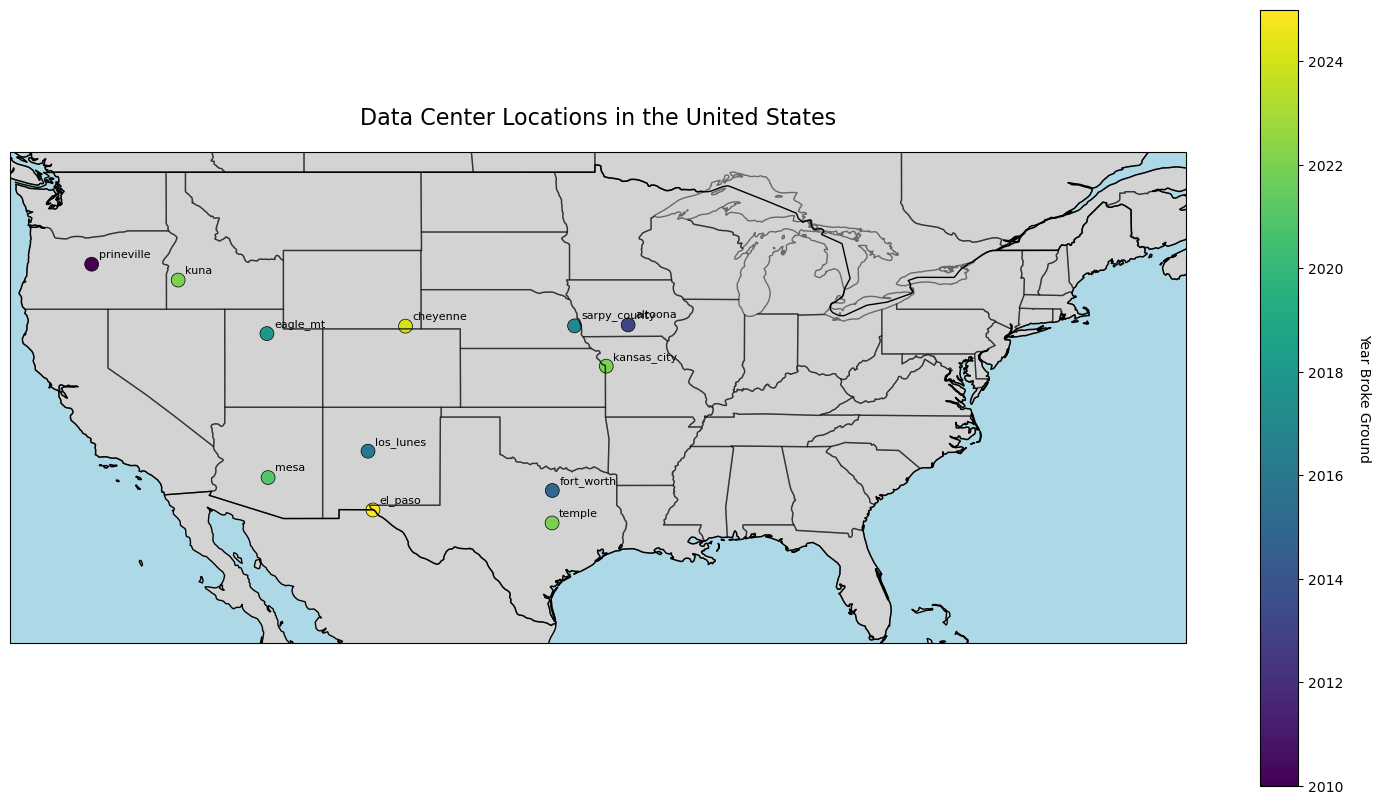

In [4]:
## viz 
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES, linestyle='-', alpha=0.5)
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.LAND, color='lightgray')

# Plot data centers
scatter = ax.scatter(data['longitude'], data['latitude'], 
                    c=data['year_broke_ground'], 
                    s=100, 
                    cmap='viridis', 
                    transform=ccrs.PlateCarree(),
                    edgecolors='black',
                    linewidth=0.5)

# Add labels for each data center
for idx, row in data.iterrows():
    ax.annotate(row['center_name'], 
                (row['longitude'], row['latitude']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, ha='left',
                transform=ccrs.PlateCarree())

# Set extent to continental US
ax.set_extent([-125, -65, 25, 50], ccrs.PlateCarree())

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label('Year Broke Ground', rotation=270, labelpad=20)

plt.title('Data Center Locations in the United States', fontsize=16, pad=20)
plt.tight_layout()
plt.show()


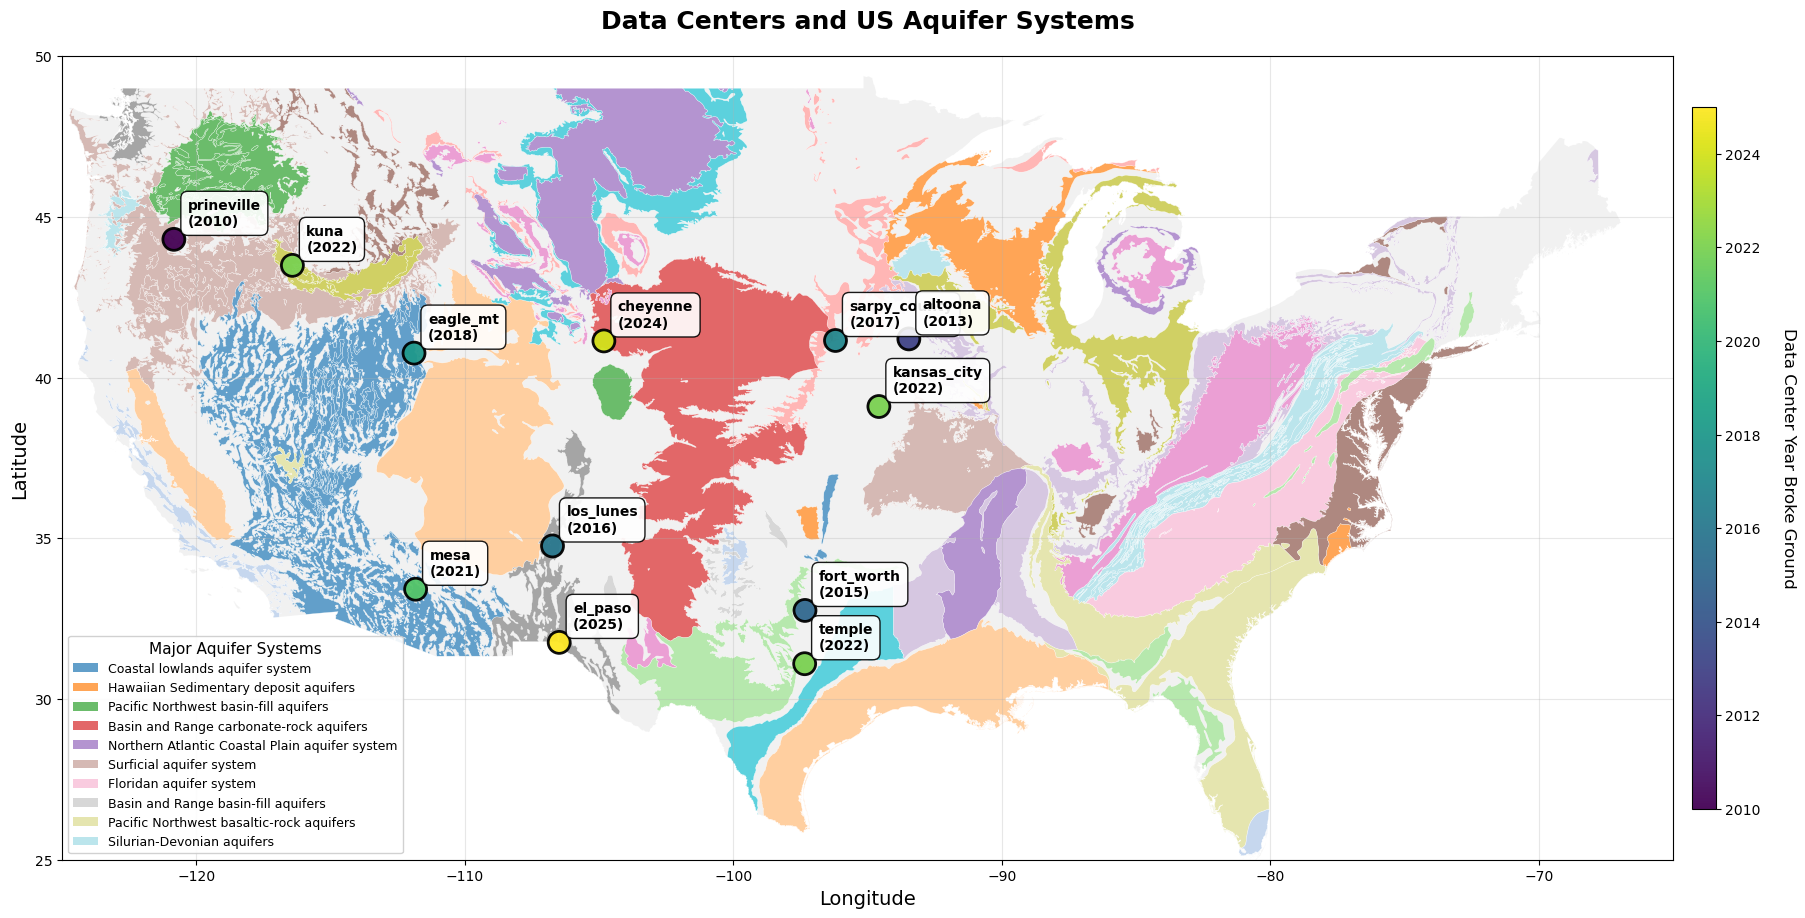


Data Centers located over aquifer systems:
  prineville, OR: Pacific Northwest basin-fill aquifers
  eagle_mt, UT: Basin and Range basin-fill aquifers
  kuna, ID: Snake River Plain basin-fill aquifers
  mesa, AZ: Basin and Range basin-fill aquifers
  cheyenne, WY: High Plains aquifer
  los_lunes, NM: Rio Grande aquifer system
  el_paso, TX: Rio Grande aquifer system
  sarpy_county, NE: Lower Cretaceous aquifers
  fort_worth, TX: Other rocks
  temple, TX: Other rocks
  kansas_city, MO: Other rocks
  altoona, IA: Other rocks


In [5]:
# Load the aquifers shapefile
aquifers = gpd.read_file('/Users/cmbreen/Downloads/aquifers_us/us_aquifers.shp')

# Create the map
fig, ax = plt.subplots(figsize=(20, 12))

# Filter out "Other rocks" for cleaner visualization (or keep them in gray)
actual_aquifers = aquifers[aquifers['AQ_NAME'] != 'Other rocks'].copy()
other_rocks = aquifers[aquifers['AQ_NAME'] == 'Other rocks'].copy()

# Plot "Other rocks" first in gray
if len(other_rocks) > 0:
    other_rocks.plot(ax=ax, 
                     color='lightgray', 
                     alpha=0.3, 
                     edgecolor='white', 
                     linewidth=0.2,
                     label='Other rocks')

# Plot actual aquifers with different colors
actual_aquifers.plot(ax=ax, 
                    column='AQ_NAME', 
                    alpha=0.7, 
                    edgecolor='white', 
                    linewidth=0.3,
                    legend=False,  # We'll create custom legend
                    cmap='tab20')  # Good for categorical data

# Plot data centers
scatter = ax.scatter(data['longitude'], data['latitude'], 
                    c=data['year_broke_ground'], 
                    s=250, 
                    cmap='viridis', 
                    edgecolors='black',
                    linewidth=2,
                    alpha=0.95,
                    zorder=10)

# Add labels for data centers
for idx, row in data.iterrows():
    ax.annotate(f"{row['center_name']}\n({row['year_broke_ground']})", 
                (row['longitude'], row['latitude']),
                xytext=(10, 10), textcoords='offset points',
                fontsize=10, ha='left', weight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='black'),
                zorder=11)

# Set extent to continental US
ax.set_xlim(-125, -65)
ax.set_ylim(25, 50)

# Styling
ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)
ax.set_title('Data Centers and US Aquifer Systems', fontsize=18, pad=20, weight='bold')
ax.grid(True, alpha=0.3)

# Add colorbar for data centers
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.01, aspect=30)
cbar.set_label('Data Center Year Broke Ground', rotation=270, labelpad=25, fontsize=12)

# Create a custom legend for major aquifers (top 10)
major_aquifers = actual_aquifers['AQ_NAME'].value_counts().head(10).index
legend_elements = []
colors = plt.cm.tab20(np.linspace(0, 1, len(major_aquifers)))

for i, aq_name in enumerate(major_aquifers):
    legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=colors[i], alpha=0.7, label=aq_name))

# Add legend
legend = ax.legend(handles=legend_elements, 
                  title='Major Aquifer Systems', 
                  loc='lower left', 
                 # bbox_to_anchor=(0.02, 0.98),
                  fontsize=9,
                  title_fontsize=11)
legend.get_frame().set_alpha(0.9)

plt.tight_layout()
plt.show()

# Print some interesting statistics
print(f"\nData Centers located over aquifer systems:")
for idx, row in data.iterrows():
    # Find which aquifer (if any) each data center is over
    point = gpd.points_from_xy([row['longitude']], [row['latitude']], crs='EPSG:4326')[0]
    
    # Check intersection with aquifers
    intersecting = aquifers[aquifers.geometry.contains(point)]
    if len(intersecting) > 0:
        aq_name = intersecting.iloc[0]['AQ_NAME']
        print(f"  {row['center_name']}, {row['state'].upper()}: {aq_name}")
    else:
        print(f"  {row['center_name']}, {row['state'].upper()}: No major aquifer")

In [6]:
## load in the NASA Grace data: 
import xarray as xr

dataset_path = "/Users/cmbreen/Documents/AISTproject/data/netcdfs/CSR_GRACE_GRACE-FO_RL0603_Mascons_all-corrections.nc"
ds = xr.open_dataset(dataset_path)

# Your Western US slice
ds_region = ds.sel(lat=slice(30, 49), lon=slice(235, 265)) #258 #32


In [7]:
ds

<xarray.Dataset> Size: 995MB
Dimensions:        (time: 240, timebound: 2, lat: 720, lon: 1440)
Coordinates:
  * time           (time) float32 960B 107.0 129.5 227.5 ... 8.355e+03 8.386e+03
  * lon            (lon) float32 6kB 0.125 0.375 0.625 ... 359.4 359.6 359.9
  * lat            (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
Dimensions without coordinates: timebound
Data variables:
    time_bounds    (time, timebound) float32 2kB ...
    lwe_thickness  (time, lat, lon) float32 995MB ...
Attributes: (12/59)
    Conventions:                CF-1.6, ACDD-1.3, ISO 8601
    filename:                   netcdf/CSR_GRACE_GRACE-FO_RL0603_Mascons_all-...
    Metadata_Conventions:       Unidata Dataset Discovery v1.0
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    title:                      CSR GRACE and GRACE-FO MASCON RL0603M
    subtitle:                   RL06.2 GRACE/GRACE-FO Total water storage wit...
    ...                         ...
    user_note_3:                Ellipsoidal correction has been applied. The ...
    user_note_4:                This GRACE-FO RL06.2 data is an updated versi...
    date_created:               2025-02-14T11:59:44Z
    variable:                   liquid water equivalent thickness
    label:                      RL0603rc24cE
    Mask:                       Global

In [10]:
import gravity_toolkit.time

grace_month_number = 200 # Example month number

year, month = gravity_toolkit.time.grace_to_calendar(grace_month_number)



In [40]:
all_extractions = {}

for idx, row in data.iterrows():
    print(f"Extracting data for {row['center_name']}, {row['state'].upper()}...")

    # Use .sel() with method='nearest' to find the closest grid point
    # Note: Fixed the coordinate assignment - lon should get longitude, lat should get latitude
    point_data = ds.sel(lon=row['longitude'], lat=row['latitude'], method='nearest')

    # Extract the time and lwe_thickness data
    times = point_data.time_bounds.values
    formatted_times = []
    grace_epoch = datetime(2002, 1, 1)
    
    for time in times:
        start_day, end_day = time[0], time[1]
        #year, month = gravity_toolkit.time.grace_to_calendar(start_day) ## in days
        date1 = grace_epoch + timedelta(days=int(start_day))
        #date2 = grace_epoch + timedelta(days=int(end_day))
        formatted_times.append(date1)
    lwe_thickness = point_data.lwe_thickness.values

    # Create the key-value pair for the dictionary
    key = (row['latitude'], row['longitude'], row['center_name'], row['state'])  # Added name and state for clarity
    value = (formatted_times, lwe_thickness)
    
    # Add to dictionary
    all_extractions[key] = value


Extracting data for prineville, OR...
Extracting data for eagle_mt, UT...
Extracting data for kuna, ID...
Extracting data for mesa, AZ...
Extracting data for cheyenne, WY...
Extracting data for los_lunes, NM...
Extracting data for el_paso, TX...
Extracting data for sarpy_county, NE...
Extracting data for fort_worth, TX...
Extracting data for temple, TX...
Extracting data for kansas_city, MO...
Extracting data for altoona, IA...


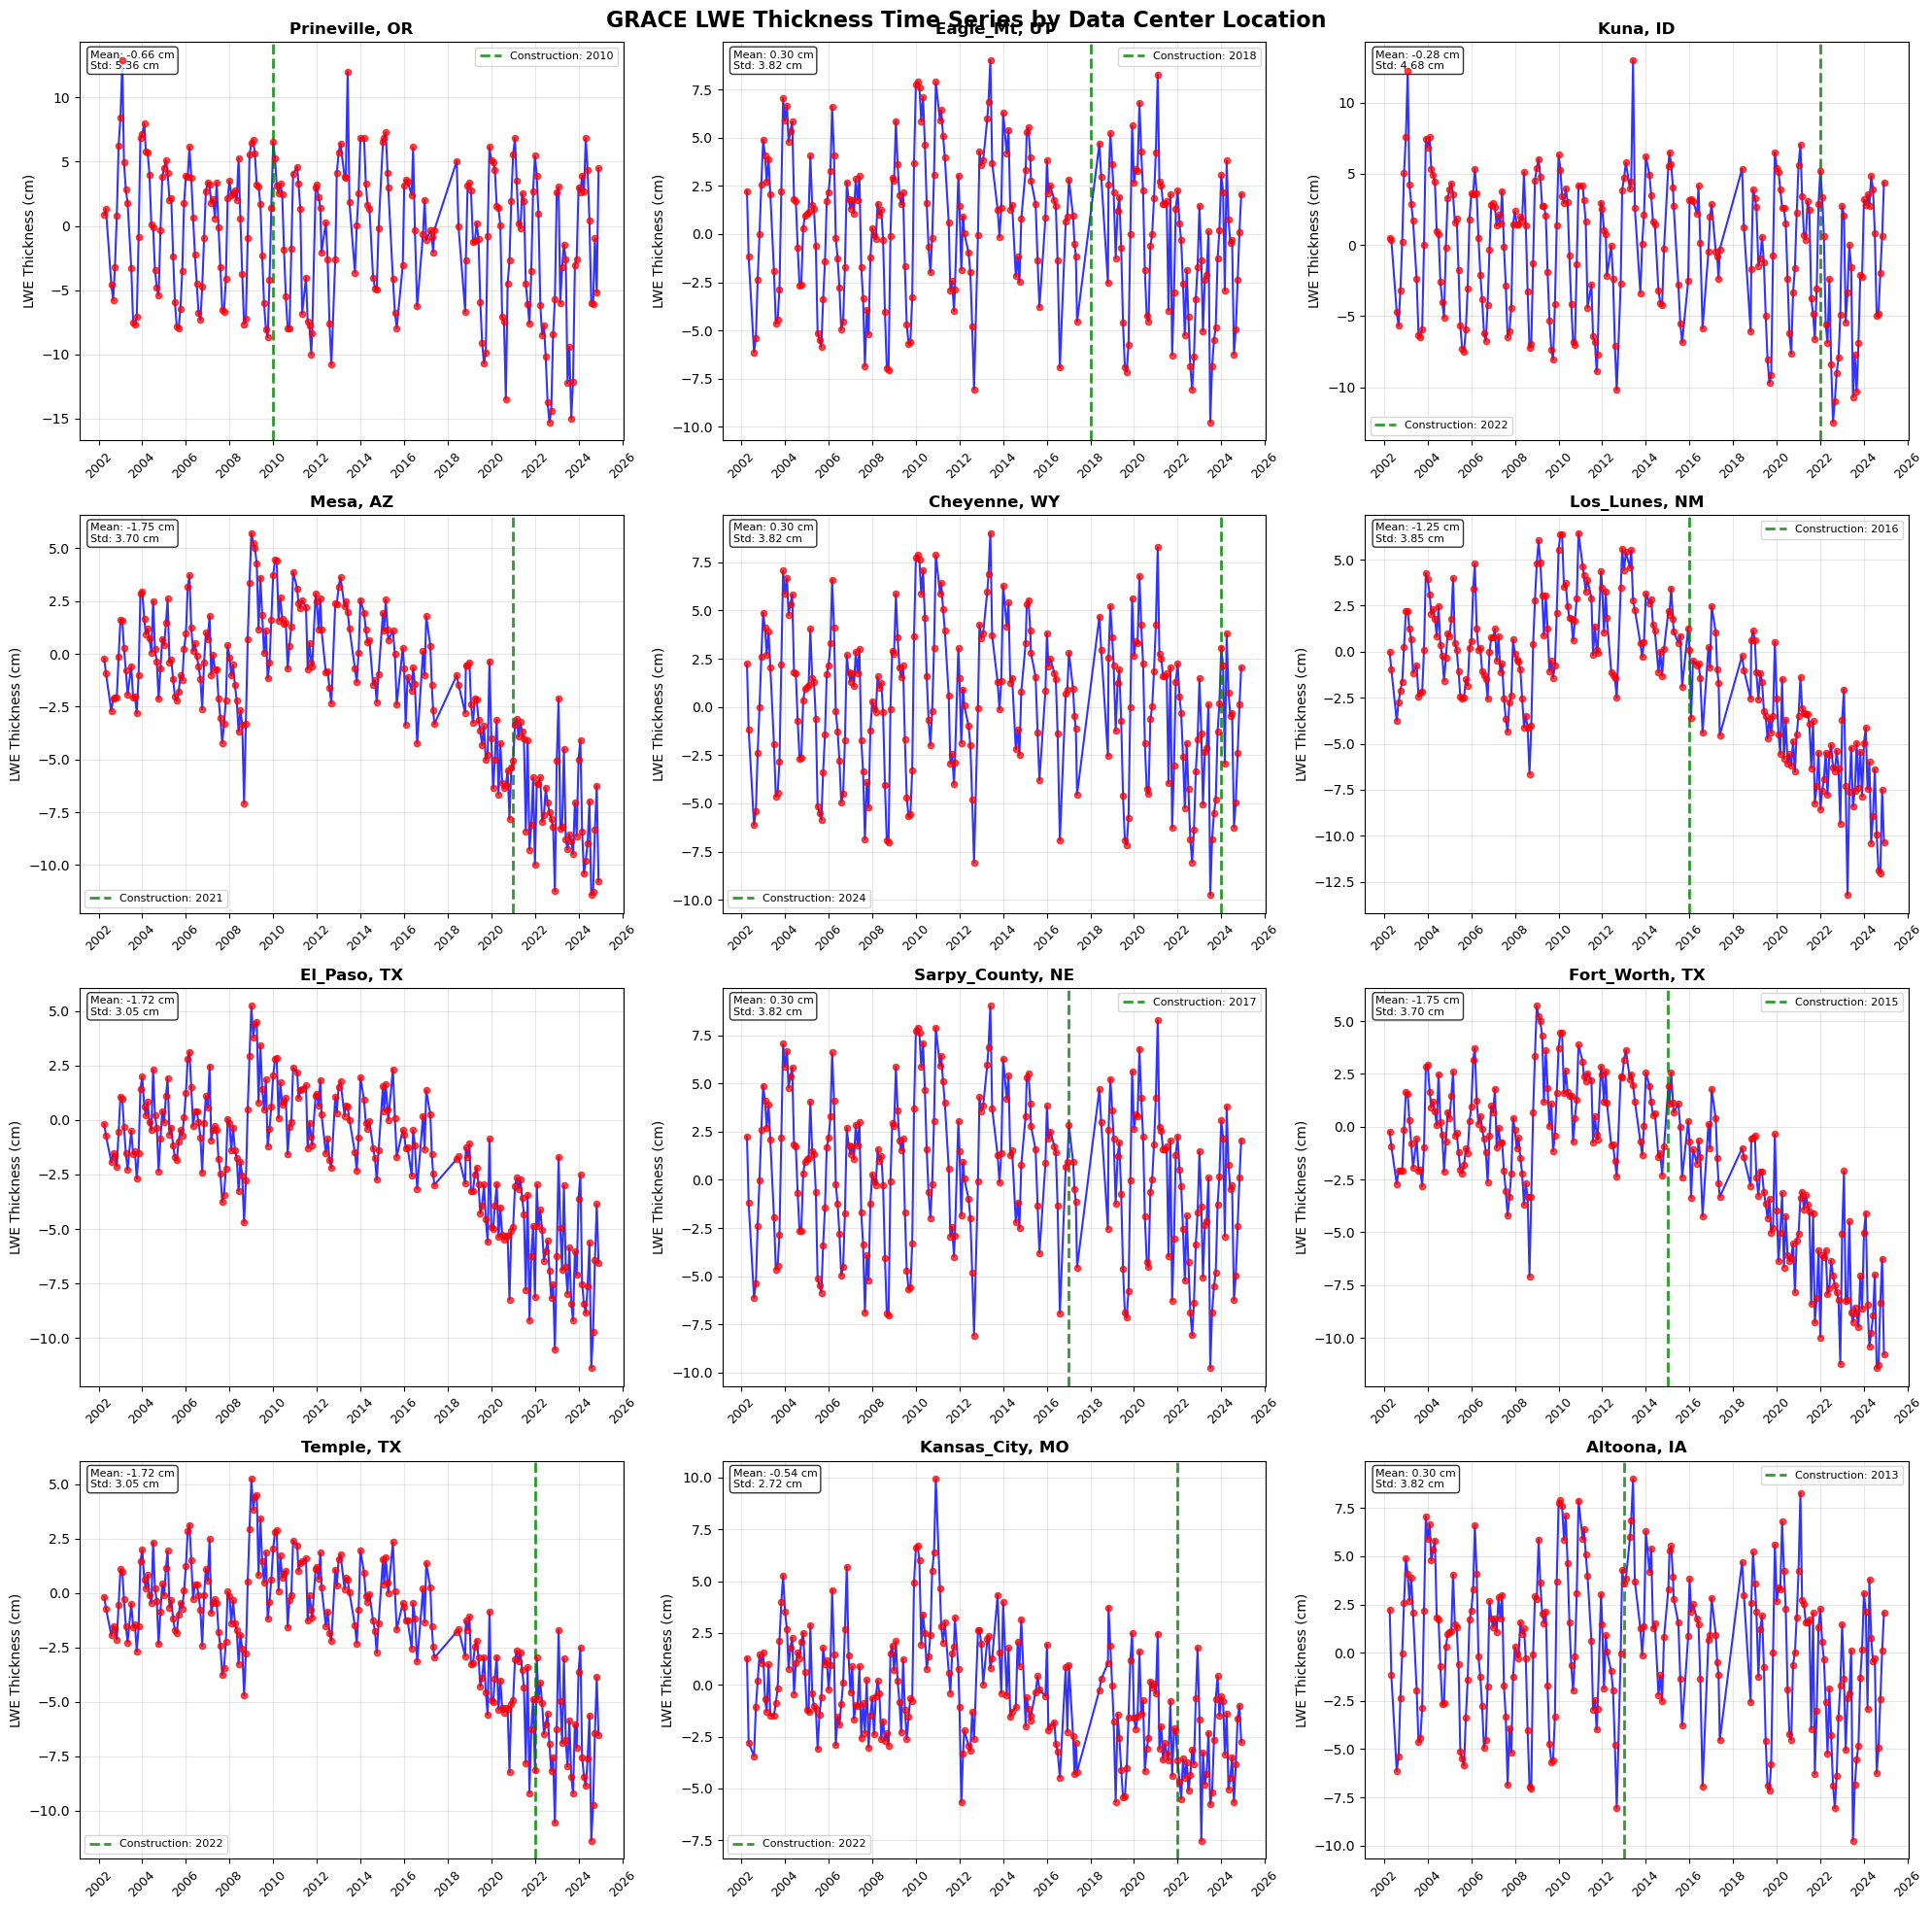

Summary Statistics:
Prineville, OR:
  Data points: 240
  Date range: Apr 2002 to Dec 2024
  LWE range: -15.27 to 12.90 cm
  Mean LWE: -0.66 ± 5.36 cm

Eagle_Mt, UT:
  Data points: 240
  Date range: Apr 2002 to Dec 2024
  LWE range: -9.76 to 9.02 cm
  Mean LWE: 0.30 ± 3.82 cm

Kuna, ID:
  Data points: 240
  Date range: Apr 2002 to Dec 2024
  LWE range: -12.45 to 12.99 cm
  Mean LWE: -0.28 ± 4.68 cm

Mesa, AZ:
  Data points: 240
  Date range: Apr 2002 to Dec 2024
  LWE range: -11.43 to 5.72 cm
  Mean LWE: -1.75 ± 3.70 cm

Cheyenne, WY:
  Data points: 240
  Date range: Apr 2002 to Dec 2024
  LWE range: -9.76 to 9.02 cm
  Mean LWE: 0.30 ± 3.82 cm

Los_Lunes, NM:
  Data points: 240
  Date range: Apr 2002 to Dec 2024
  LWE range: -13.22 to 6.44 cm
  Mean LWE: -1.25 ± 3.85 cm

El_Paso, TX:
  Data points: 240
  Date range: Apr 2002 to Dec 2024
  LWE range: -11.38 to 5.24 cm
  Mean LWE: -1.72 ± 3.05 cm

Sarpy_County, NE:
  Data points: 240
  Date range: Apr 2002 to Dec 2024
  LWE range: -9.76 t

In [41]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import numpy as np

# Create subplots for all locations
n_locations = len(all_extractions)
n_cols = 3  # 3 columns
n_rows = int(np.ceil(n_locations / n_cols))  # Calculate needed rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()  # Make it easier to iterate

# Plot each location
for i, (key, (formatted_times, lwe_thickness)) in enumerate(all_extractions.items()):
    lat, lon, center_name, state = key
    
    # Plot the time series
    axes[i].plot(formatted_times, lwe_thickness, 'b-', linewidth=1.5, alpha=0.8)
    axes[i].scatter(formatted_times, lwe_thickness, c='red', s=20, alpha=0.7, zorder=5)
    
    # Formatting
    axes[i].set_title(f'{center_name.title()}, {state.upper()}', fontsize=12, weight='bold')
    axes[i].set_ylabel('LWE Thickness (cm)', fontsize=10)
    axes[i].grid(True, alpha=0.3)
    
    # Format x-axis dates
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].xaxis.set_major_locator(mdates.YearLocator(2))  # Every 2 years
    axes[i].tick_params(axis='x', rotation=45, labelsize=9)
    
    # Add vertical line at construction year
    construction_year = row['year_broke_ground'] if 'row' in locals() else None
    # Get construction year from original data
    construction_year = data[data['center_name'] == center_name]['year_broke_ground'].iloc[0]
    if construction_year <= 2024:  # Only if construction has happened
        construction_date = datetime(construction_year, 1, 1)
        axes[i].axvline(x=construction_date, color='green', linestyle='--', 
                       alpha=0.8, linewidth=2, label=f'Construction: {construction_year}')
        axes[i].legend(fontsize=8)
    
    # Add some statistics
    mean_lwe = np.mean(lwe_thickness)
    std_lwe = np.std(lwe_thickness)
    axes[i].text(0.02, 0.98, f'Mean: {mean_lwe:.2f} cm\nStd: {std_lwe:.2f} cm', 
                transform=axes[i].transAxes, fontsize=8, 
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Hide empty subplots
for i in range(n_locations, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('GRACE LWE Thickness Time Series by Data Center Location', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary Statistics:")
print("="*50)
for key, (formatted_times, lwe_thickness) in all_extractions.items():
    lat, lon, center_name, state = key
    print(f"{center_name.title()}, {state.upper()}:")
    print(f"  Data points: {len(lwe_thickness)}")
    print(f"  Date range: {formatted_times[0].strftime('%b %Y')} to {formatted_times[-1].strftime('%b %Y')}")
    print(f"  LWE range: {np.min(lwe_thickness):.2f} to {np.max(lwe_thickness):.2f} cm")
    print(f"  Mean LWE: {np.mean(lwe_thickness):.2f} ± {np.std(lwe_thickness):.2f} cm")
    print()

In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime

def calculate_before_after_means(all_extractions, data):
    """
    Calculate mean LWE thickness before and after data center construction
    """
    results = []
    
    for key, (formatted_times, lwe_thickness) in all_extractions.items():
        lat, lon, center_name, state = key
        
        # Get construction year
        construction_year = data[data['center_name'] == center_name]['year_broke_ground'].iloc[0]
        construction_date = datetime(construction_year, 1, 1)
        
        # Convert to arrays for easier handling
        times_array = np.array(formatted_times)
        lwe_array = np.array(lwe_thickness)
        
        # Split data into before and after construction
        before_mask = times_array < construction_date
        after_mask = times_array >= construction_date
        
        before_lwe = lwe_array[before_mask]
        after_lwe = lwe_array[after_mask]
        
        # Calculate statistics
        if len(before_lwe) > 0:
            mean_before = np.mean(before_lwe)
            std_before = np.std(before_lwe)
            n_before = len(before_lwe)
        else:
            mean_before = np.nan
            std_before = np.nan
            n_before = 0
            
        if len(after_lwe) > 0:
            mean_after = np.mean(after_lwe)
            std_after = np.std(after_lwe)
            n_after = len(after_lwe)
        else:
            mean_after = np.nan
            std_after = np.nan
            n_after = 0
        
        # Calculate difference
        if not np.isnan(mean_before) and not np.isnan(mean_after):
            difference = mean_after - mean_before
            percent_change = (difference / abs(mean_before)) * 100
        else:
            difference = np.nan
            percent_change = np.nan
        
        # Get date ranges
        if n_before > 0:
            before_start = times_array[before_mask][0].strftime('%b %Y')
            before_end = times_array[before_mask][-1].strftime('%b %Y')
        else:
            before_start = "N/A"
            before_end = "N/A"
            
        if n_after > 0:
            after_start = times_array[after_mask][0].strftime('%b %Y')
            after_end = times_array[after_mask][-1].strftime('%b %Y')
        else:
            after_start = "N/A"
            after_end = "N/A"
        
        results.append({
            'location': f"{center_name.title()}, {state.upper()}",
            'center_name': center_name,
            'state': state,
            'construction_year': construction_year,
            'total_data_points': len(lwe_thickness),
            'n_before': n_before,
            'n_after': n_after,
            'before_period': f"{before_start} - {before_end}" if n_before > 0 else "No data",
            'after_period': f"{after_start} - {after_end}" if n_after > 0 else "No data",
            'mean_before': mean_before,
            'std_before': std_before,
            'mean_after': mean_after,
            'std_after': std_after,
            'difference': difference,
            'percent_change': percent_change
        })
    
    return pd.DataFrame(results)

# Calculate the before/after analysis
analysis_df = calculate_before_after_means(all_extractions, data)

# Display results
print("GRACE LWE Thickness: Before vs After Data Center Construction")
print("=" * 80)

for idx, row in analysis_df.iterrows():
    print(f"\n{row['location']}")
    print(f"Construction Year: {row['construction_year']}")
    print(f"Total Data Points: {row['total_data_points']}")
    
    if row['n_before'] > 0:
        print(f"BEFORE Construction ({row['before_period']}):")
        print(f"  • Data points: {row['n_before']}")
        print(f"  • Mean LWE: {row['mean_before']:.3f} ± {row['std_before']:.3f} cm")
    else:
        print(f"BEFORE Construction: No data available")
    
    if row['n_after'] > 0:
        print(f"AFTER Construction ({row['after_period']}):")
        print(f"  • Data points: {row['n_after']}")
        print(f"  • Mean LWE: {row['mean_after']:.3f} ± {row['std_after']:.3f} cm")
    else:
        print(f"AFTER Construction: No data available")
    
    if not np.isnan(row['difference']):
        direction = "DECREASE" if row['difference'] < 0 else "INCREASE"
        print(f"CHANGE: {row['difference']:.3f} cm ({row['percent_change']:.1f}% {direction})")
    else:
        print(f"CHANGE: Cannot calculate (insufficient data)")

# Summary table
print("\n\nSUMMARY TABLE:")
print("=" * 80)
summary_cols = ['location', 'construction_year', 'n_before', 'n_after', 
                'mean_before', 'mean_after', 'difference', 'percent_change']

summary_display = analysis_df[summary_cols].copy()
for col in ['mean_before', 'mean_after', 'difference', 'percent_change']:
    summary_display[col] = summary_display[col].round(3)

print(summary_display.to_string(index=False))

# Save to CSV
analysis_df.to_csv('grace_before_after_analysis.csv', index=False)
print(f"\nDetailed results saved to 'grace_before_after_analysis.csv'")

# Statistical summary
print(f"\n\nSTATISTICAL SUMMARY:")
print(f"Locations with before AND after data: {analysis_df['difference'].notna().sum()}")
print(f"Locations showing decrease: {(analysis_df['difference'] < 0).sum()}")
print(f"Locations showing increase: {(analysis_df['difference'] > 0).sum()}")

if analysis_df['difference'].notna().sum() > 0:
    valid_changes = analysis_df['difference'].dropna()
    print(f"Mean change across all locations: {valid_changes.mean():.3f} cm")
    print(f"Median change across all locations: {valid_changes.median():.3f} cm")



# SUMMARY TABLE:
# ================================================================================
#         location  construction_year  n_before  n_after  mean_before  mean_after  difference  percent_change
#   Prineville, OR               2010        90      150        0.079      -1.108      -1.187       -1510.386
#     Eagle_Mt, UT               2018       163       77        0.767      -0.693      -1.459        -190.330
#         Kuna, ID               2022       204       36        0.104      -2.485      -2.589       -2480.127
#         Mesa, AZ               2021       192       48       -0.396      -7.175      -6.779       -1711.181
#     Cheyenne, WY               2024       228       12        0.338      -0.443      -0.780        -231.110
#    Los_Lunes, NM               2016       149       91        0.786      -4.591      -5.377        -684.215
#      El_Paso, TX               2025       240        0       -1.724         NaN         NaN             NaN
# Sarpy_County, NE               2017       158       82        0.806      -0.680      -1.486        -184.316
#   Fort_Worth, TX               2015       140      100        0.323      -4.656      -4.979       -1543.219
#       Temple, TX               2022       204       36       -0.888      -6.464      -5.576        -628.263
#  Kansas_City, MO               2022       204       36       -0.082      -3.165      -3.083       -3754.849
#      Altoona, IA               2013       122      118        0.452       0.140      -0.313         -69.112


GRACE LWE Thickness: Before vs After Data Center Construction

Prineville, OR
Construction Year: 2010
Total Data Points: 240
BEFORE Construction (Apr 2002 - Dec 2009):
  • Data points: 90
  • Mean LWE: 0.079 ± 4.865 cm
AFTER Construction (Jan 2010 - Dec 2024):
  • Data points: 150
  • Mean LWE: -1.108 ± 5.583 cm
CHANGE: -1.187 cm (-1510.4% DECREASE)

Eagle_Mt, UT
Construction Year: 2018
Total Data Points: 240
BEFORE Construction (Apr 2002 - May 2017):
  • Data points: 163
  • Mean LWE: 0.767 ± 3.716 cm
AFTER Construction (Jun 2018 - Dec 2024):
  • Data points: 77
  • Mean LWE: -0.693 ± 3.854 cm
CHANGE: -1.459 cm (-190.3% DECREASE)

Kuna, ID
Construction Year: 2022
Total Data Points: 240
BEFORE Construction (Apr 2002 - Dec 2021):
  • Data points: 204
  • Mean LWE: 0.104 ± 4.477 cm
AFTER Construction (Jan 2022 - Dec 2024):
  • Data points: 36
  • Mean LWE: -2.485 ± 5.150 cm
CHANGE: -2.589 cm (-2480.1% DECREASE)

Mesa, AZ
Construction Year: 2021
Total Data Points: 240
BEFORE Construction 

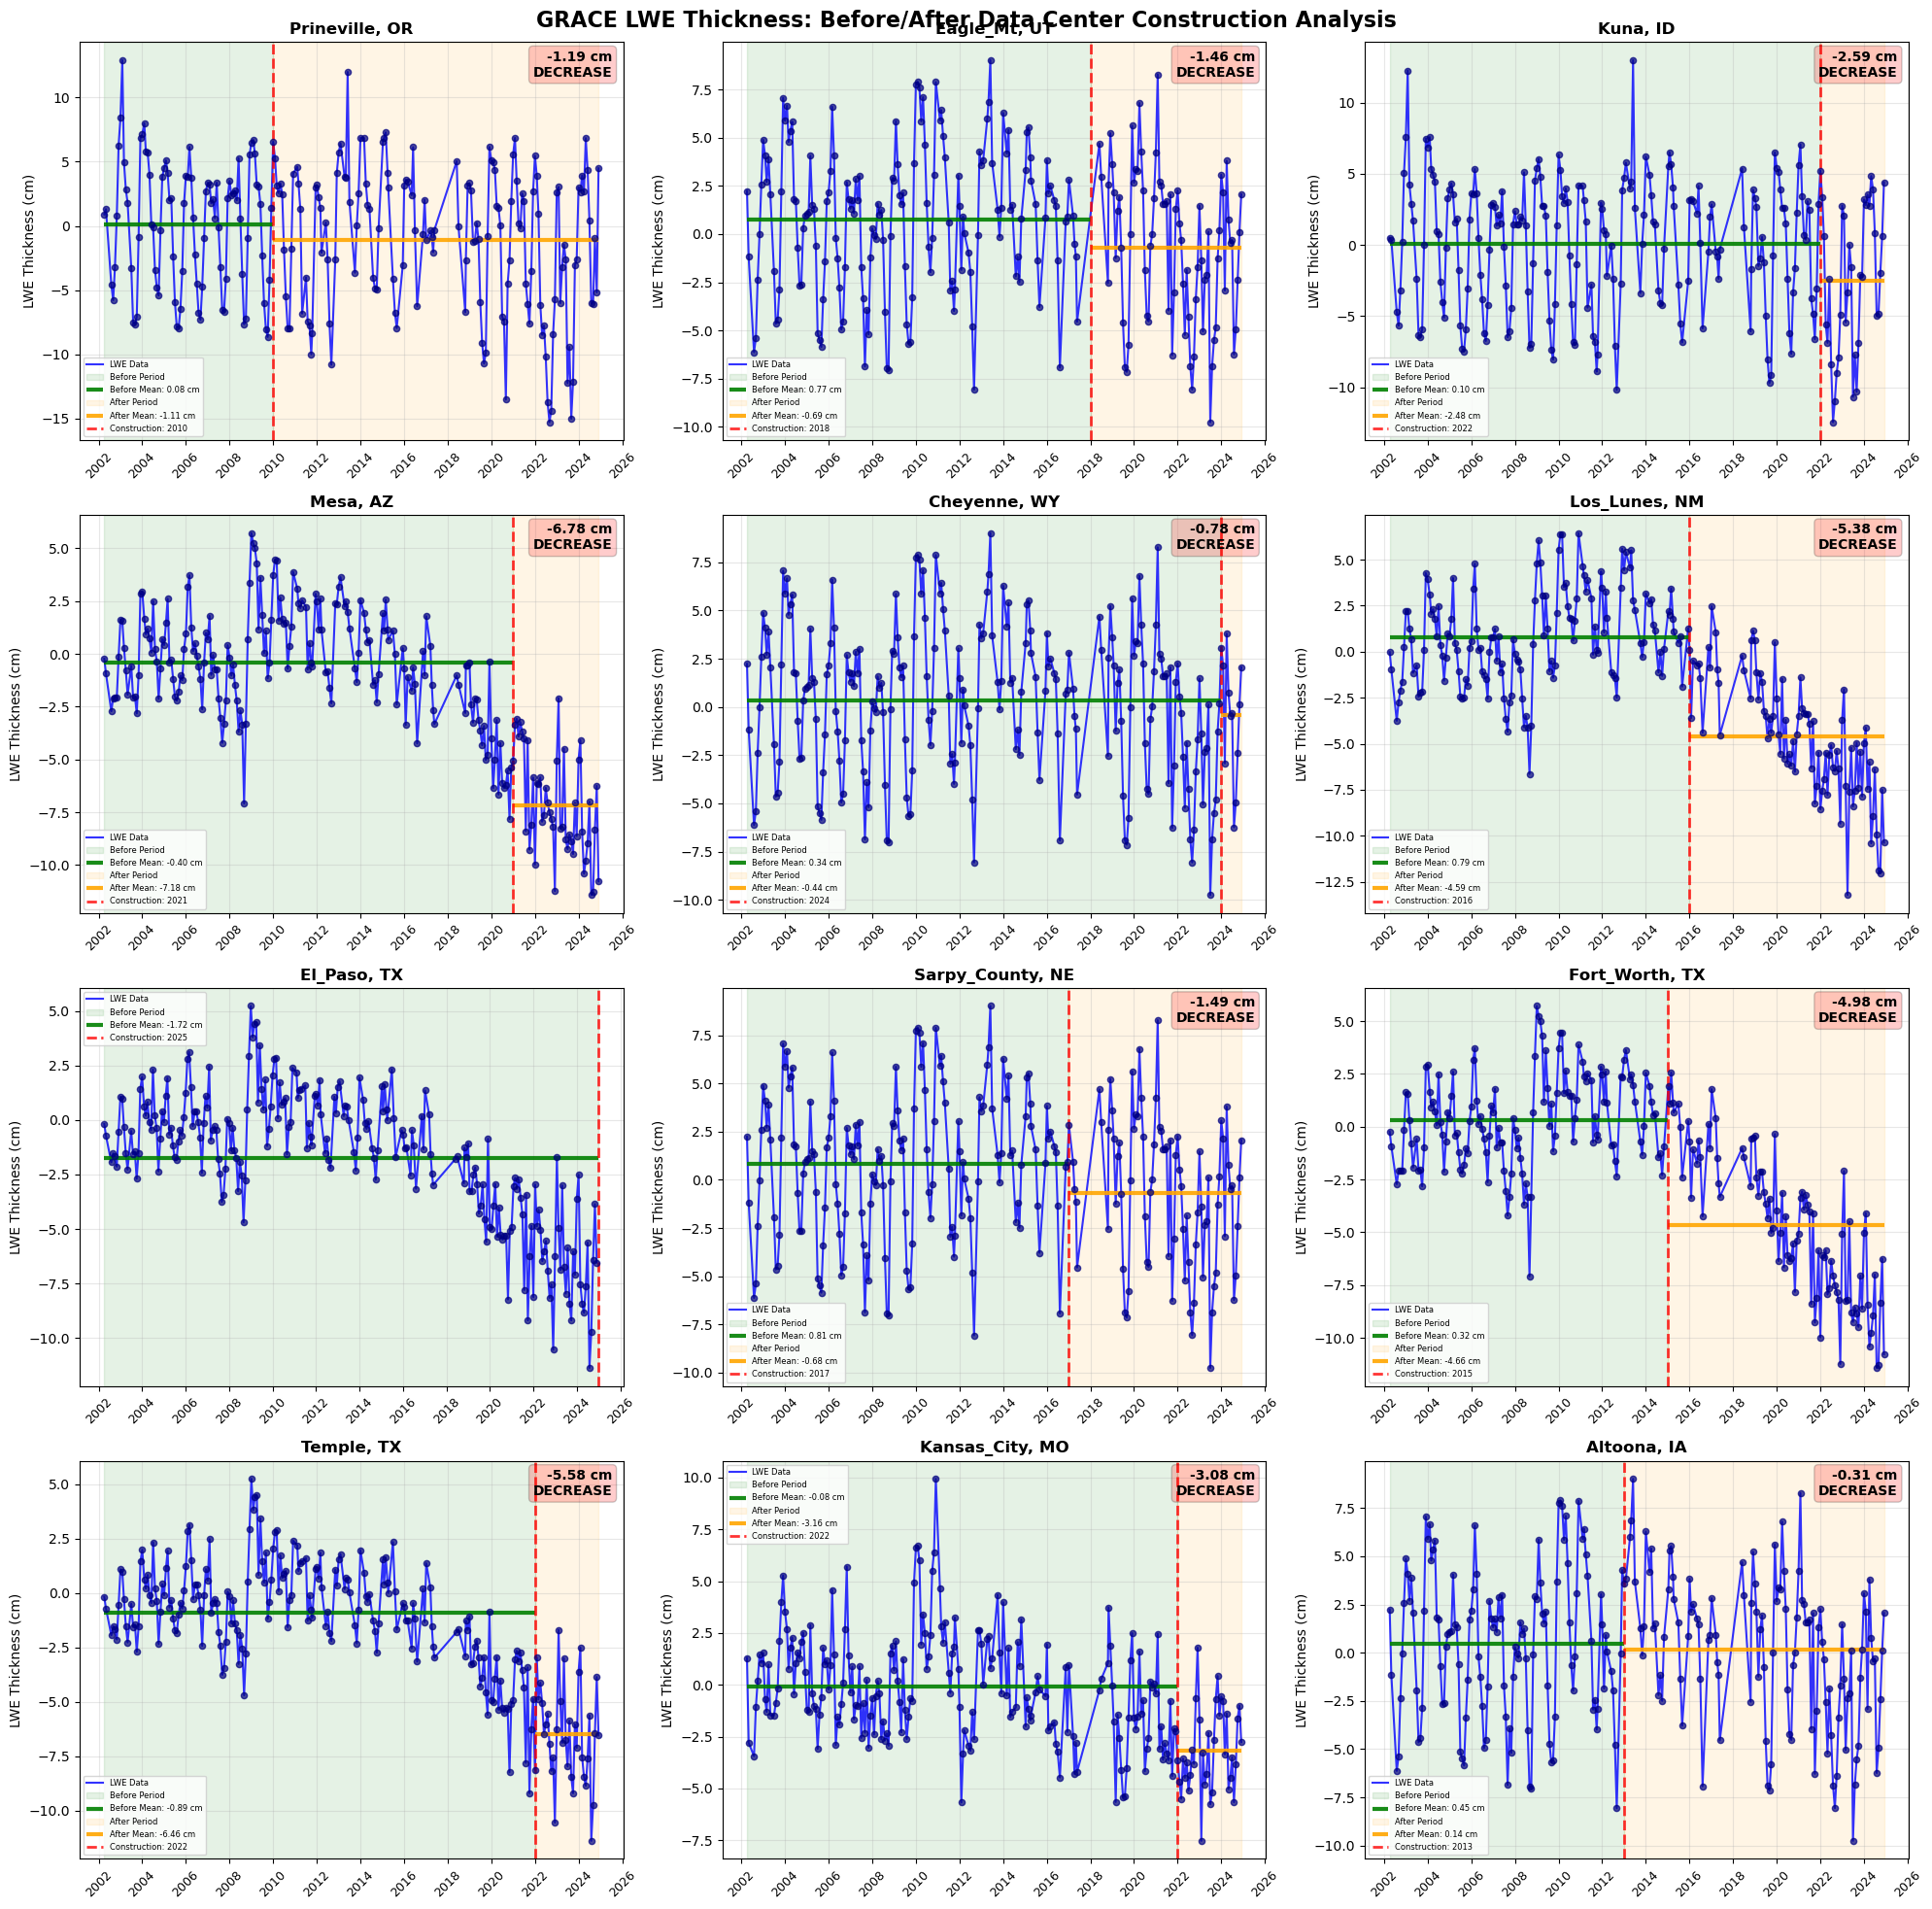

In [43]:
# Alternative version with full-width mean lines and shaded regions
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, (key, (formatted_times, lwe_thickness)) in enumerate(all_extractions.items()):
    lat, lon, center_name, state = key
    
    # Get the analysis results for this location
    location_name = f"{center_name.title()}, {state.upper()}"
    analysis_row = analysis_df[analysis_df['location'] == location_name].iloc[0]
    
    construction_year = analysis_row['construction_year']
    construction_date = datetime(construction_year, 1, 1)
    
    times_array = np.array(formatted_times)
    lwe_array = np.array(lwe_thickness)
    
    # Plot the main time series
    axes[i].plot(formatted_times, lwe_thickness, 'b-', linewidth=1.5, alpha=0.8, label='LWE Data')
    axes[i].scatter(formatted_times, lwe_thickness, c='navy', s=20, alpha=0.7, zorder=5)
    
    # Add shaded regions for before/after periods
    min_date = min(formatted_times)
    max_date = max(formatted_times)
    y_min, y_max = axes[i].get_ylim()
    
    # Before construction shading
    if analysis_row['n_before'] > 0:
        axes[i].axvspan(min_date, construction_date, alpha=0.1, color='green', label='Before Period')
        # Before mean line (full width for that period)
        axes[i].hlines(y=analysis_row['mean_before'], xmin=min_date, xmax=construction_date,
                      colors='green', linestyles='-', linewidth=3, alpha=0.9,
                      label=f'Before Mean: {analysis_row["mean_before"]:.2f} cm')
    
    # After construction shading  
    if analysis_row['n_after'] > 0:
        axes[i].axvspan(construction_date, max_date, alpha=0.1, color='orange', label='After Period')
        # After mean line (full width for that period)
        axes[i].hlines(y=analysis_row['mean_after'], xmin=construction_date, xmax=max_date,
                      colors='orange', linestyles='-', linewidth=3, alpha=0.9,
                      label=f'After Mean: {analysis_row["mean_after"]:.2f} cm')
    
    # Construction line
    axes[i].axvline(x=construction_date, color='red', linestyle='--', 
                   alpha=0.8, linewidth=2, label=f'Construction: {construction_year}')
    
    # Formatting
    axes[i].set_title(f'{center_name.title()}, {state.upper()}', fontsize=12, weight='bold')
    axes[i].set_ylabel('LWE Thickness (cm)', fontsize=10)
    axes[i].grid(True, alpha=0.3)
    
    # Format dates
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[i].tick_params(axis='x', rotation=45, labelsize=9)
    
    # Compact legend
    axes[i].legend(fontsize=6, loc='best')
    
    # Statistics box
    if not np.isnan(analysis_row['difference']):
        change_color = 'red' if analysis_row['difference'] < 0 else 'blue'
        direction = "DECREASE" if analysis_row['difference'] < 0 else "INCREASE"
        stats_text = f'{analysis_row["difference"]:.2f} cm\n{direction}'
        
        axes[i].text(0.98, 0.98, stats_text, 
                    transform=axes[i].transAxes, fontsize=10, weight='bold',
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=change_color, alpha=0.2))

# Hide empty subplots
for i in range(n_locations, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('GRACE LWE Thickness: Before/After Data Center Construction Analysis', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from scipy import stats
from sklearn.linear_model import LinearRegression
import pandas as pd

def find_optimal_breakpoint(times, values, min_points=10):
    """
    Find the optimal breakpoint using residual sum of squares minimization
    """
    n = len(times)
    if n < 2 * min_points:
        return None, None, None, None, None
    
    # Convert times to numeric (days since first observation)
    time_numeric = np.array([(t - times[0]).days for t in times])
    
    best_breakpoint = None
    best_rss = float('inf')
    best_models = None
    best_r2 = -1
    
    # Try different breakpoints (avoid first and last min_points)
    for i in range(min_points, n - min_points):
        # Split data at potential breakpoint
        x1, y1 = time_numeric[:i], values[:i]
        x2, y2 = time_numeric[i:], values[i:]
        
        # Fit linear models for each segment
        if len(x1) >= 3 and len(x2) >= 3:  # Need at least 3 points for meaningful regression
            model1 = LinearRegression().fit(x1.reshape(-1, 1), y1)
            model2 = LinearRegression().fit(x2.reshape(-1, 1), y2)
            
            # Calculate predictions and residuals
            pred1 = model1.predict(x1.reshape(-1, 1))
            pred2 = model2.predict(x2.reshape(-1, 1))
            
            # Calculate residual sum of squares
            rss1 = np.sum((y1 - pred1) ** 2)
            rss2 = np.sum((y2 - pred2) ** 2)
            total_rss = rss1 + rss2
            
            # Calculate R-squared for combined model
            y_pred_combined = np.concatenate([pred1, pred2])
            y_actual = np.concatenate([y1, y2])
            ss_res = np.sum((y_actual - y_pred_combined) ** 2)
            ss_tot = np.sum((y_actual - np.mean(y_actual)) ** 2)
            r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            # Update best breakpoint
            if total_rss < best_rss:
                best_rss = total_rss
                best_breakpoint = i
                best_models = (model1, model2)
                best_r2 = r2
    
    if best_breakpoint is not None:
        breakpoint_date = times[best_breakpoint]
        return best_breakpoint, breakpoint_date, best_models, best_rss, best_r2
    else:
        return None, None, None, None, None

def perform_breakpoint_analysis(all_extractions, data):
    """
    Perform breakpoint regression analysis for all locations
    """
    results = []
    
    for key, (formatted_times, lwe_thickness) in all_extractions.items():
        lat, lon, center_name, state = key
        
        # Get construction year for reference
        construction_year = data[data['center_name'] == center_name]['year_broke_ground'].iloc[0]
        construction_date = datetime(construction_year, 1, 1)
        
        print(f"Analyzing {center_name.title()}, {state.upper()}...")
        
        # Find optimal breakpoint
        bp_idx, bp_date, models, rss, r2 = find_optimal_breakpoint(formatted_times, lwe_thickness)
        
        if bp_idx is not None:
            # Calculate statistics for each segment
            times_array = np.array(formatted_times)
            lwe_array = np.array(lwe_thickness)
            
            # Before breakpoint
            before_times = times_array[:bp_idx]
            before_lwe = lwe_array[:bp_idx]
            mean_before = np.mean(before_lwe)
            std_before = np.std(before_lwe)
            
            # After breakpoint
            after_times = times_array[bp_idx:]
            after_lwe = lwe_array[bp_idx:]
            mean_after = np.mean(after_lwe)
            std_after = np.std(after_lwe)
            
            # Calculate change
            difference = mean_after - mean_before
            percent_change = (difference / abs(mean_before)) * 100 if mean_before != 0 else 0
            
            # Time difference between breakpoint and construction
            time_diff_years = (bp_date - construction_date).days / 365.25
            
            model1, model2 = models
            
            results.append({
                'location': f"{center_name.title()}, {state.upper()}",
                'center_name': center_name,
                'state': state,
                'construction_date': construction_date,
                'breakpoint_date': bp_date,
                'time_diff_years': time_diff_years,
                'breakpoint_index': bp_idx,
                'total_points': len(lwe_thickness),
                'points_before': len(before_lwe),
                'points_after': len(after_lwe),
                'mean_before': mean_before,
                'std_before': std_before,
                'mean_after': mean_after,
                'std_after': std_after,
                'difference': difference,
                'percent_change': percent_change,
                'slope_before': model1.coef_[0],
                'slope_after': model2.coef_[0],
                'r_squared': r2,
                'residual_sum_squares': rss
            })
        else:
            results.append({
                'location': f"{center_name.title()}, {state.upper()}",
                'center_name': center_name,
                'state': state,
                'construction_date': construction_date,
                'breakpoint_date': None,
                'time_diff_years': None,
                'breakpoint_index': None,
                'total_points': len(lwe_thickness),
                'points_before': 0,
                'points_after': 0,
                'mean_before': np.nan,
                'std_before': np.nan,
                'mean_after': np.nan,
                'std_after': np.nan,
                'difference': np.nan,
                'percent_change': np.nan,
                'slope_before': np.nan,
                'slope_after': np.nan,
                'r_squared': np.nan,
                'residual_sum_squares': np.nan
            })
    
    return pd.DataFrame(results)

# Perform the breakpoint analysis
breakpoint_results = perform_breakpoint_analysis(all_extractions, data)

# Display results
print("\nBREAKPOINT REGRESSION ANALYSIS RESULTS")
print("=" * 80)

for idx, row in breakpoint_results.iterrows():
    print(f"\n{row['location']}")
    print(f"Construction Date: {row['construction_date'].strftime('%b %Y')}")
    
    if pd.notna(row['breakpoint_date']):
        print(f"Optimal Breakpoint: {row['breakpoint_date'].strftime('%b %Y')}")
        print(f"Time Difference: {row['time_diff_years']:.1f} years {'after' if row['time_diff_years'] > 0 else 'before'} construction")
        print(f"R-squared: {row['r_squared']:.3f}")
        
        print(f"BEFORE Breakpoint ({row['points_before']} points):")
        print(f"  • Mean LWE: {row['mean_before']:.3f} ± {row['std_before']:.3f} cm")
        print(f"  • Trend: {row['slope_before']:.4f} cm/day")
        
        print(f"AFTER Breakpoint ({row['points_after']} points):")
        print(f"  • Mean LWE: {row['mean_after']:.3f} ± {row['std_after']:.3f} cm")
        print(f"  • Trend: {row['slope_after']:.4f} cm/day")
        
        direction = "DECREASE" if row['difference'] < 0 else "INCREASE"
        print(f"CHANGE: {row['difference']:.3f} cm ({row['percent_change']:.1f}% {direction})")
    else:
        print("No significant breakpoint found")

# Summary statistics
print(f"\n\nSUMMARY:")
valid_results = breakpoint_results.dropna(subset=['breakpoint_date'])
print(f"Locations with significant breakpoints: {len(valid_results)}")
if len(valid_results) > 0:
    print(f"Average time difference from construction: {valid_results['time_diff_years'].mean():.1f} years")
    print(f"Breakpoints before construction: {(valid_results['time_diff_years'] < 0).sum()}")
    print(f"Breakpoints after construction: {(valid_results['time_diff_years'] > 0).sum()}")
    print(f"Locations showing decrease after breakpoint: {(valid_results['difference'] < 0).sum()}")
    print(f"Locations showing increase after breakpoint: {(valid_results['difference'] > 0).sum()}")

# Save results
breakpoint_results.to_csv('grace_breakpoint_analysis.csv', index=False)
print(f"\nResults saved to 'grace_breakpoint_analysis.csv'")

Analyzing Prineville, OR...
Analyzing Eagle_Mt, UT...
Analyzing Kuna, ID...
Analyzing Mesa, AZ...
Analyzing Cheyenne, WY...
Analyzing Los_Lunes, NM...
Analyzing El_Paso, TX...
Analyzing Sarpy_County, NE...
Analyzing Fort_Worth, TX...
Analyzing Temple, TX...
Analyzing Kansas_City, MO...
Analyzing Altoona, IA...

BREAKPOINT REGRESSION ANALYSIS RESULTS

Prineville, OR
Construction Date: Jan 2010
Optimal Breakpoint: Apr 2022
Time Difference: 12.2 years after construction
R-squared: 0.130
BEFORE Breakpoint (207 points):
  • Mean LWE: -0.082 ± 4.943 cm
  • Trend: -0.0001 cm/day
AFTER Breakpoint (33 points):
  • Mean LWE: -4.310 ± 6.319 cm
  • Trend: 0.0116 cm/day
CHANGE: -4.228 cm (-5166.9% DECREASE)

Eagle_Mt, UT
Construction Date: Jan 2018
Optimal Breakpoint: Dec 2009
Time Difference: -8.1 years before construction
R-squared: 0.120
BEFORE Breakpoint (89 points):
  • Mean LWE: -0.010 ± 3.588 cm
  • Trend: -0.0009 cm/day
AFTER Breakpoint (151 points):
  • Mean LWE: 0.481 ± 3.942 cm
  • Trend

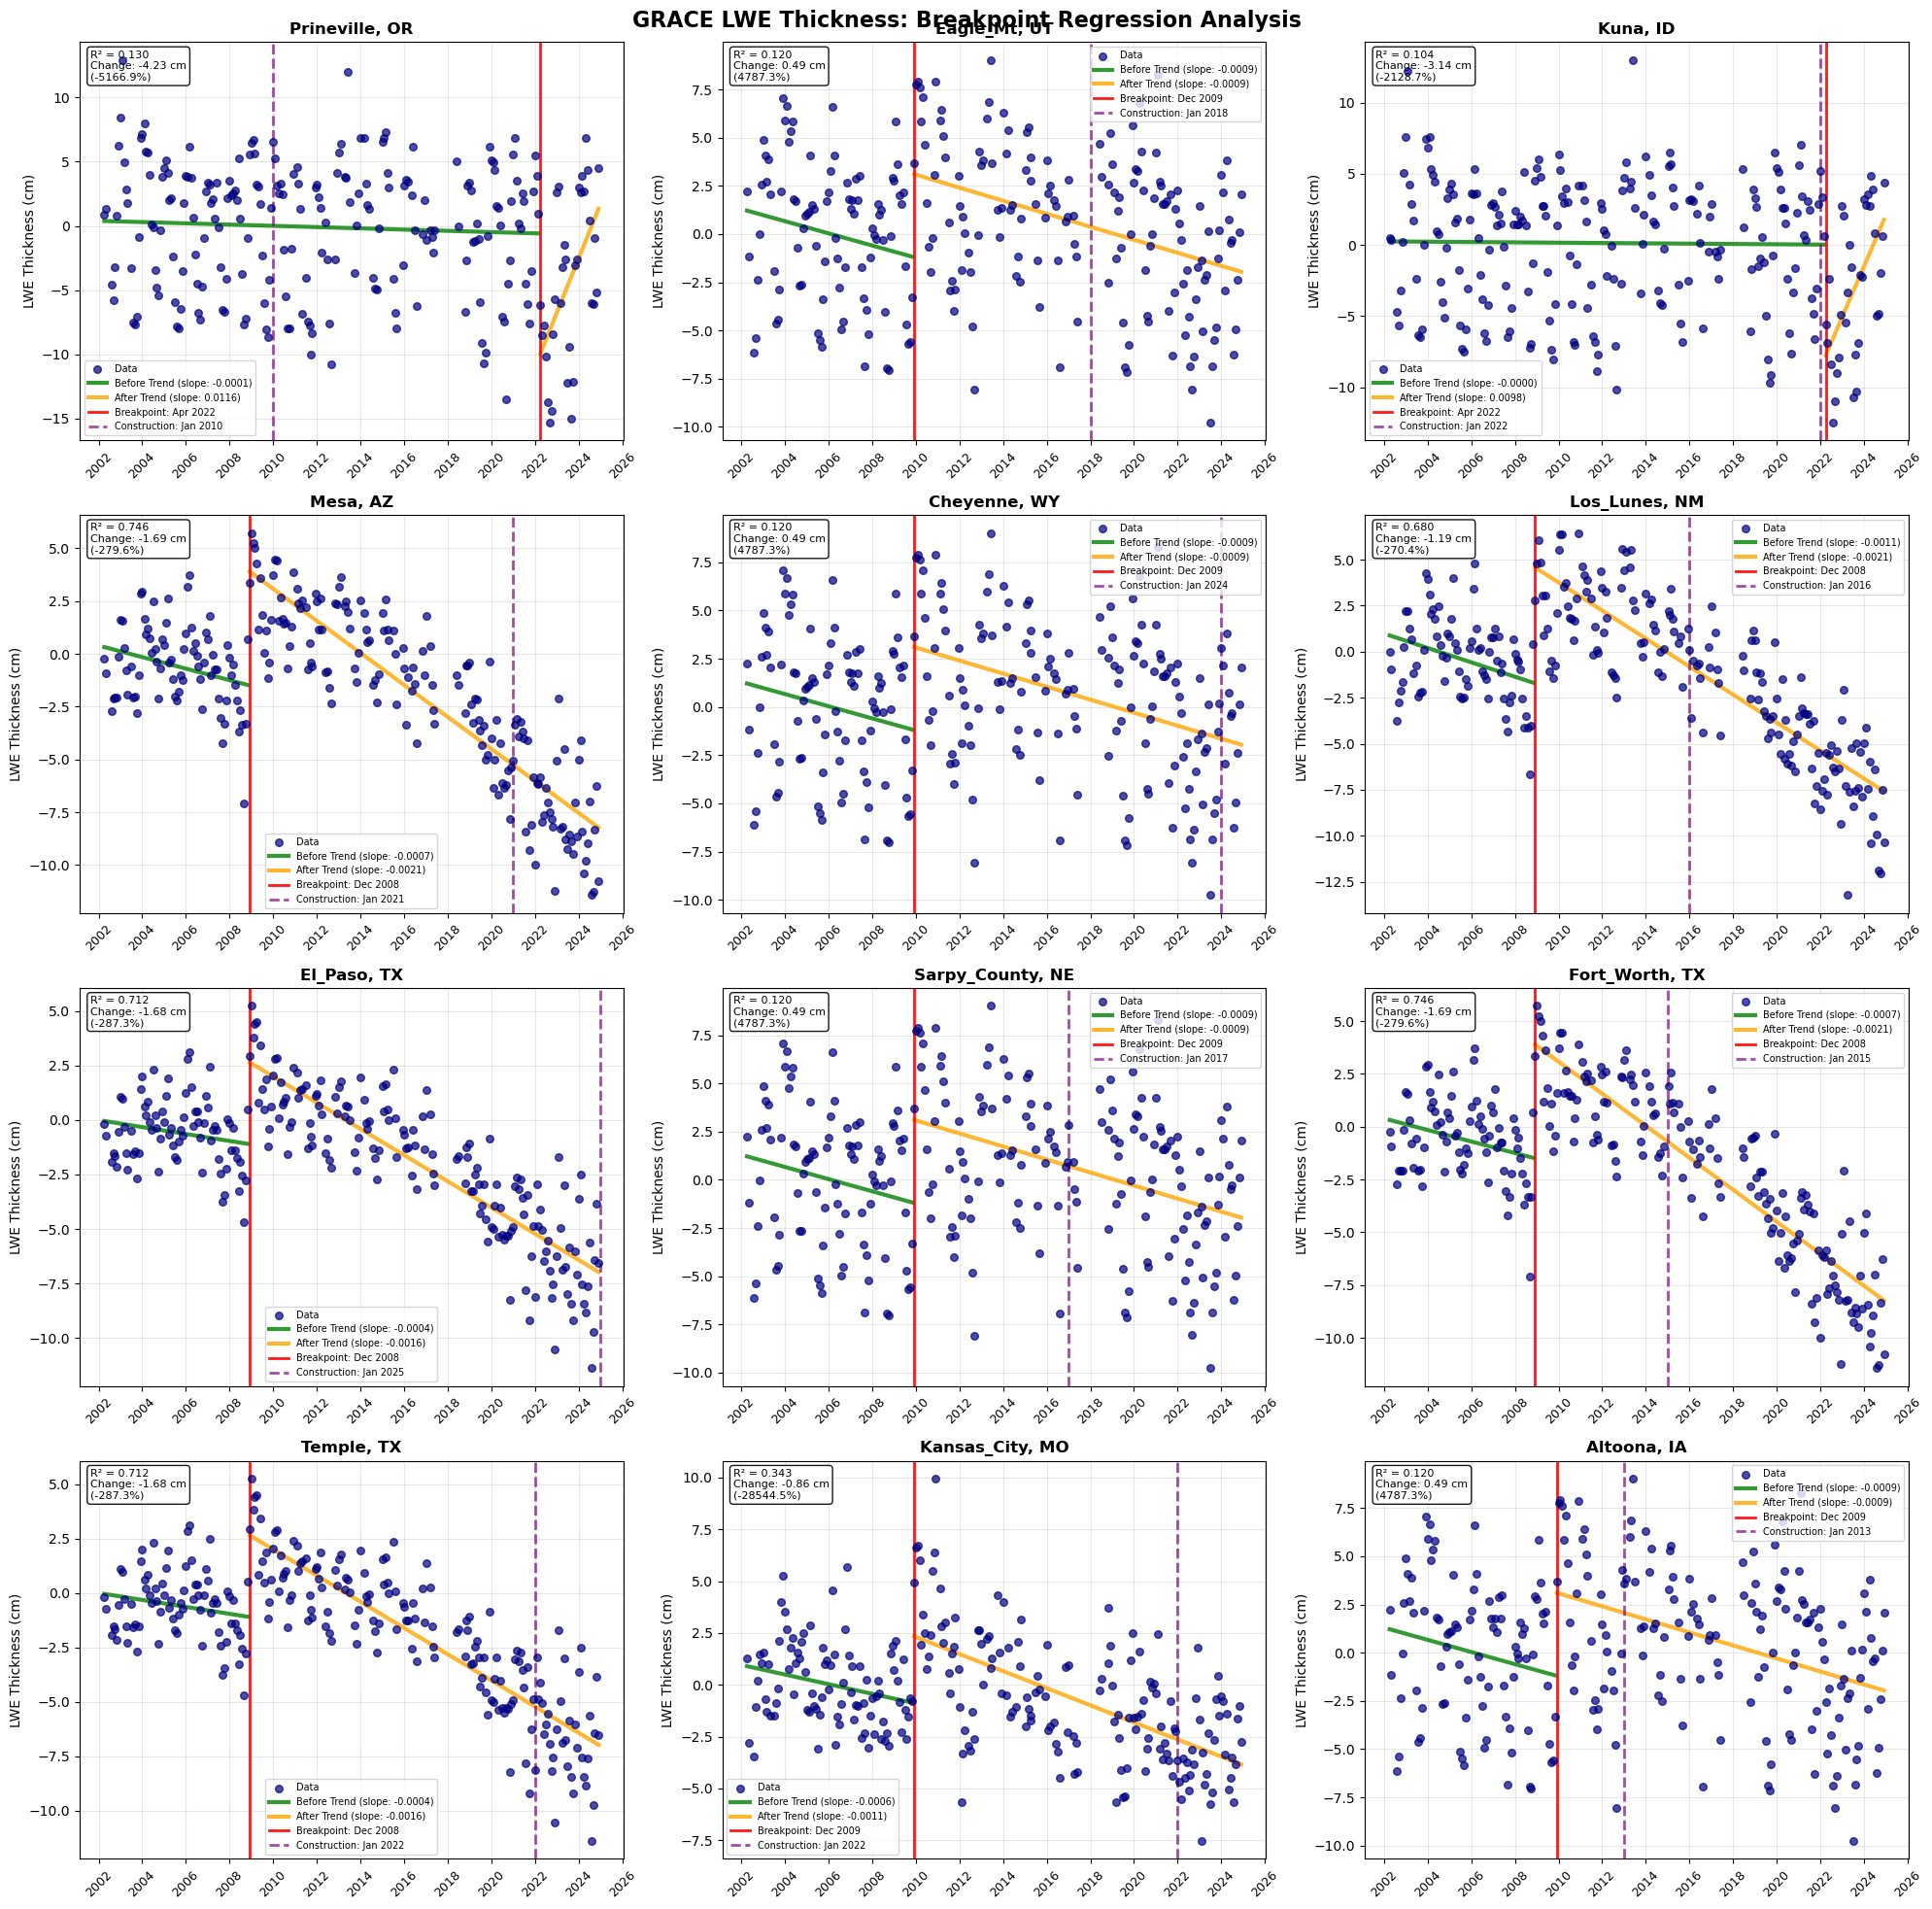

In [45]:
# Plot results with breakpoint regression lines
n_locations = len(all_extractions)
n_cols = 3
n_rows = int(np.ceil(n_locations / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, (key, (formatted_times, lwe_thickness)) in enumerate(all_extractions.items()):
    lat, lon, center_name, state = key
    
    # Get results for this location
    location_name = f"{center_name.title()}, {state.upper()}"
    result_row = breakpoint_results[breakpoint_results['location'] == location_name].iloc[0]
    
    construction_date = result_row['construction_date']
    times_array = np.array(formatted_times)
    lwe_array = np.array(lwe_thickness)
    
    # Plot original data
    axes[i].scatter(formatted_times, lwe_thickness, c='navy', s=30, alpha=0.7, zorder=5, label='Data')
    
    # If breakpoint was found, plot the regression segments
    if pd.notna(result_row['breakpoint_date']):
        bp_date = result_row['breakpoint_date']
        bp_idx = result_row['breakpoint_index']
        
        # Convert times to numeric for regression lines
        time_numeric = np.array([(t - times_array[0]).days for t in times_array])
        
        # Recreate the models for plotting
        x1, y1 = time_numeric[:bp_idx], lwe_array[:bp_idx]
        x2, y2 = time_numeric[bp_idx:], lwe_array[bp_idx:]
        
        if len(x1) >= 3 and len(x2) >= 3:
            model1 = LinearRegression().fit(x1.reshape(-1, 1), y1)
            model2 = LinearRegression().fit(x2.reshape(-1, 1), y2)
            
            # Plot regression lines
            pred1 = model1.predict(x1.reshape(-1, 1))
            pred2 = model2.predict(x2.reshape(-1, 1))
            
            axes[i].plot(times_array[:bp_idx], pred1, 'g-', linewidth=3, alpha=0.8, 
                        label=f'Before Trend (slope: {model1.coef_[0]:.4f})')
            axes[i].plot(times_array[bp_idx:], pred2, 'orange', linewidth=3, alpha=0.8,
                        label=f'After Trend (slope: {model2.coef_[0]:.4f})')
        
        # Mark the breakpoint
        axes[i].axvline(x=bp_date, color='red', linestyle='-', linewidth=2, alpha=0.9,
                       label=f'Breakpoint: {bp_date.strftime("%b %Y")}')
        
        # Mark construction date for comparison
        axes[i].axvline(x=construction_date, color='purple', linestyle='--', linewidth=2, alpha=0.7,
                       label=f'Construction: {construction_date.strftime("%b %Y")}')
    else:
        # No breakpoint found - just plot a simple trend line
        time_numeric = np.array([(t - times_array[0]).days for t in times_array])
        simple_model = LinearRegression().fit(time_numeric.reshape(-1, 1), lwe_array)
        simple_pred = simple_model.predict(time_numeric.reshape(-1, 1))
        axes[i].plot(times_array, simple_pred, 'gray', linewidth=2, alpha=0.8,
                    label=f'Overall Trend (slope: {simple_model.coef_[0]:.4f})')
        
        axes[i].axvline(x=construction_date, color='purple', linestyle='--', linewidth=2, alpha=0.7,
                       label=f'Construction: {construction_date.strftime("%b %Y")}')
    
    # Formatting
    axes[i].set_title(f'{center_name.title()}, {state.upper()}', fontsize=12, weight='bold')
    axes[i].set_ylabel('LWE Thickness (cm)', fontsize=10)
    axes[i].grid(True, alpha=0.3)
    
    # Format dates
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[i].tick_params(axis='x', rotation=45, labelsize=9)
    
    # Add legend and stats
    axes[i].legend(fontsize=7, loc='best')
    
    # Statistics box
    if pd.notna(result_row['difference']):
        stats_text = f"R² = {result_row['r_squared']:.3f}\n"
        stats_text += f"Change: {result_row['difference']:.2f} cm\n"
        stats_text += f"({result_row['percent_change']:.1f}%)"
        
        axes[i].text(0.02, 0.98, stats_text, transform=axes[i].transAxes, 
                    fontsize=8, verticalalignment='top',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

# Hide empty subplots
for i in range(n_locations, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('GRACE LWE Thickness: Breakpoint Regression Analysis', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from sklearn.linear_model import LinearRegression
import pandas as pd
from scipy import stats

def fixed_breakpoint_analysis(all_extractions, data):
    """
    Perform breakpoint regression with breakpoint fixed at construction date
    """
    results = []
    
    for key, (formatted_times, lwe_thickness) in all_extractions.items():
        lat, lon, center_name, state = key
        
        # Get construction year
        construction_year = data[data['center_name'] == center_name]['year_broke_ground'].iloc[0]
        construction_date = datetime(construction_year, 1, 1)
        
        print(f"Analyzing {center_name.title()}, {state.upper()}...")
        
        # Convert to arrays
        times_array = np.array(formatted_times)
        lwe_array = np.array(lwe_thickness)
        
        # Split data at construction date
        before_mask = times_array < construction_date
        after_mask = times_array >= construction_date
        
        before_times = times_array[before_mask]
        before_lwe = lwe_array[before_mask]
        after_times = times_array[after_mask]
        after_lwe = lwe_array[after_mask]
        
        # Initialize variables
        slope_before = np.nan
        intercept_before = np.nan
        r2_before = np.nan
        p_value_before = np.nan
        slope_after = np.nan
        intercept_after = np.nan
        r2_after = np.nan
        p_value_after = np.nan
        slope_difference = np.nan
        slope_change_significant = False
        
        # Fit regression for BEFORE period (need at least 3 points)
        if len(before_times) >= 3:
            # Convert times to numeric (days since first observation)
            before_numeric = np.array([(t - before_times[0]).days for t in before_times])
            model_before = LinearRegression().fit(before_numeric.reshape(-1, 1), before_lwe)
            
            slope_before = model_before.coef_[0]  # cm/day
            intercept_before = model_before.intercept_
            
            # Calculate R-squared and p-value
            pred_before = model_before.predict(before_numeric.reshape(-1, 1))
            ss_res = np.sum((before_lwe - pred_before) ** 2)
            ss_tot = np.sum((before_lwe - np.mean(before_lwe)) ** 2)
            r2_before = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            # Statistical significance test
            slope_stats, intercept_stats, r_value, p_value_before, std_err = stats.linregress(before_numeric, before_lwe)
        
        # Fit regression for AFTER period (need at least 3 points)
        if len(after_times) >= 3:
            # Convert times to numeric (days since first observation in after period)
            after_numeric = np.array([(t - after_times[0]).days for t in after_times])
            model_after = LinearRegression().fit(after_numeric.reshape(-1, 1), after_lwe)
            
            slope_after = model_after.coef_[0]  # cm/day
            intercept_after = model_after.intercept_
            
            # Calculate R-squared and p-value
            pred_after = model_after.predict(after_numeric.reshape(-1, 1))
            ss_res = np.sum((after_lwe - pred_after) ** 2)
            ss_tot = np.sum((after_lwe - np.mean(after_lwe)) ** 2)
            r2_after = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            # Statistical significance test
            slope_stats, intercept_stats, r_value, p_value_after, std_err = stats.linregress(after_numeric, after_lwe)
        
        # Calculate slope difference and significance
        if not np.isnan(slope_before) and not np.isnan(slope_after):
            slope_difference = slope_after - slope_before
            # Simple significance test: if both slopes are significant and different sign or large difference
            if p_value_before < 0.05 or p_value_after < 0.05:
                slope_change_significant = abs(slope_difference) > 0.001  # Threshold for meaningful change
        
        # Calculate mean values for comparison
        mean_before = np.mean(before_lwe) if len(before_lwe) > 0 else np.nan
        mean_after = np.mean(after_lwe) if len(after_lwe) > 0 else np.nan
        
        results.append({
            'location': f"{center_name.title()}, {state.upper()}",
            'center_name': center_name,
            'state': state,
            'construction_date': construction_date,
            'total_points': len(lwe_thickness),
            'points_before': len(before_lwe),
            'points_after': len(after_lwe),
            'mean_before': mean_before,
            'mean_after': mean_after,
            'slope_before': slope_before,  # cm/day
            'slope_after': slope_after,   # cm/day
            'slope_difference': slope_difference,  # cm/day
            'slope_before_annual': slope_before * 365.25 if not np.isnan(slope_before) else np.nan,  # cm/year
            'slope_after_annual': slope_after * 365.25 if not np.isnan(slope_after) else np.nan,   # cm/year
            'slope_diff_annual': slope_difference * 365.25 if not np.isnan(slope_difference) else np.nan, # cm/year
            'r2_before': r2_before,
            'r2_after': r2_after,
            'p_value_before': p_value_before,
            'p_value_after': p_value_after,
            'slope_change_significant': slope_change_significant
        })
    
    return pd.DataFrame(results)

# Perform the analysis
trend_results = fixed_breakpoint_analysis(all_extractions, data)

# Display results
print("FIXED BREAKPOINT TREND ANALYSIS (Construction Date)")
print("=" * 80)

for idx, row in trend_results.iterrows():
    print(f"\n{row['location']}")
    print(f"Construction Date: {row['construction_date'].strftime('%b %Y')}")
    print(f"Data Points: {row['points_before']} before, {row['points_after']} after")
    
    if row['points_before'] >= 3:
        significance = "**" if row['p_value_before'] < 0.05 else ""
        print(f"BEFORE Construction:")
        print(f"  • Trend: {row['slope_before_annual']:.3f} cm/year {significance}")
        print(f"  • R²: {row['r2_before']:.3f}, p-value: {row['p_value_before']:.3f}")
        print(f"  • Mean LWE: {row['mean_before']:.3f} cm")
    else:
        print(f"BEFORE Construction: Insufficient data ({row['points_before']} points)")
    
    if row['points_after'] >= 3:
        significance = "**" if row['p_value_after'] < 0.05 else ""
        print(f"AFTER Construction:")
        print(f"  • Trend: {row['slope_after_annual']:.3f} cm/year {significance}")
        print(f"  • R²: {row['r2_after']:.3f}, p-value: {row['p_value_after']:.3f}")
        print(f"  • Mean LWE: {row['mean_after']:.3f} cm")
    else:
        print(f"AFTER Construction: Insufficient data ({row['points_after']} points)")
    
    if not np.isnan(row['slope_diff_annual']):
        change_type = "ACCELERATION" if row['slope_diff_annual'] > 0 else "DECELERATION"
        significant_mark = " ***SIGNIFICANT***" if row['slope_change_significant'] else ""
        print(f"TREND CHANGE: {row['slope_diff_annual']:.3f} cm/year ({change_type}){significant_mark}")

# Summary statistics
print(f"\n\nSUMMARY STATISTICS:")
print("=" * 50)

valid_comparisons = trend_results.dropna(subset=['slope_diff_annual'])
print(f"Locations with before AND after trends: {len(valid_comparisons)}")

if len(valid_comparisons) > 0:
    acceleration = valid_comparisons[valid_comparisons['slope_diff_annual'] > 0]
    deceleration = valid_comparisons[valid_comparisons['slope_diff_annual'] < 0]
    
    print(f"Locations showing acceleration: {len(acceleration)}")
    print(f"Locations showing deceleration: {len(deceleration)}")
    print(f"Significant changes: {valid_comparisons['slope_change_significant'].sum()}")
    
    print(f"\nAverage trend change: {valid_comparisons['slope_diff_annual'].mean():.3f} cm/year")
    print(f"Median trend change: {valid_comparisons['slope_diff_annual'].median():.3f} cm/year")
    
    # Most extreme changes
    max_accel = valid_comparisons.loc[valid_comparisons['slope_diff_annual'].idxmax()]
    max_decel = valid_comparisons.loc[valid_comparisons['slope_diff_annual'].idxmin()]
    
    print(f"\nLargest acceleration: {max_accel['location']} (+{max_accel['slope_diff_annual']:.3f} cm/year)")
    print(f"Largest deceleration: {max_decel['location']} ({max_decel['slope_diff_annual']:.3f} cm/year)")

# Save results
trend_results.to_csv('grace_trend_analysis_construction.csv', index=False)
print(f"\nResults saved to 'grace_trend_analysis_construction.csv'")

Analyzing Prineville, OR...
Analyzing Eagle_Mt, UT...
Analyzing Kuna, ID...
Analyzing Mesa, AZ...
Analyzing Cheyenne, WY...
Analyzing Los_Lunes, NM...
Analyzing El_Paso, TX...
Analyzing Sarpy_County, NE...
Analyzing Fort_Worth, TX...
Analyzing Temple, TX...
Analyzing Kansas_City, MO...
Analyzing Altoona, IA...
FIXED BREAKPOINT TREND ANALYSIS (Construction Date)

Prineville, OR
Construction Date: Jan 2010
Data Points: 90 before, 150 after
BEFORE Construction:
  • Trend: -0.257 cm/year 
  • R²: 0.013, p-value: 0.277
  • Mean LWE: 0.079 cm
AFTER Construction:
  • Trend: -0.253 cm/year **
  • R²: 0.043, p-value: 0.011
  • Mean LWE: -1.108 cm
TREND CHANGE: 0.005 cm/year (ACCELERATION)

Eagle_Mt, UT
Construction Date: Jan 2018
Data Points: 163 before, 77 after
BEFORE Construction:
  • Trend: 0.071 cm/year 
  • R²: 0.007, p-value: 0.301
  • Mean LWE: 0.767 cm
AFTER Construction:
  • Trend: -0.643 cm/year **
  • R²: 0.096, p-value: 0.006
  • Mean LWE: -0.693 cm
TREND CHANGE: -0.714 cm/year (DE

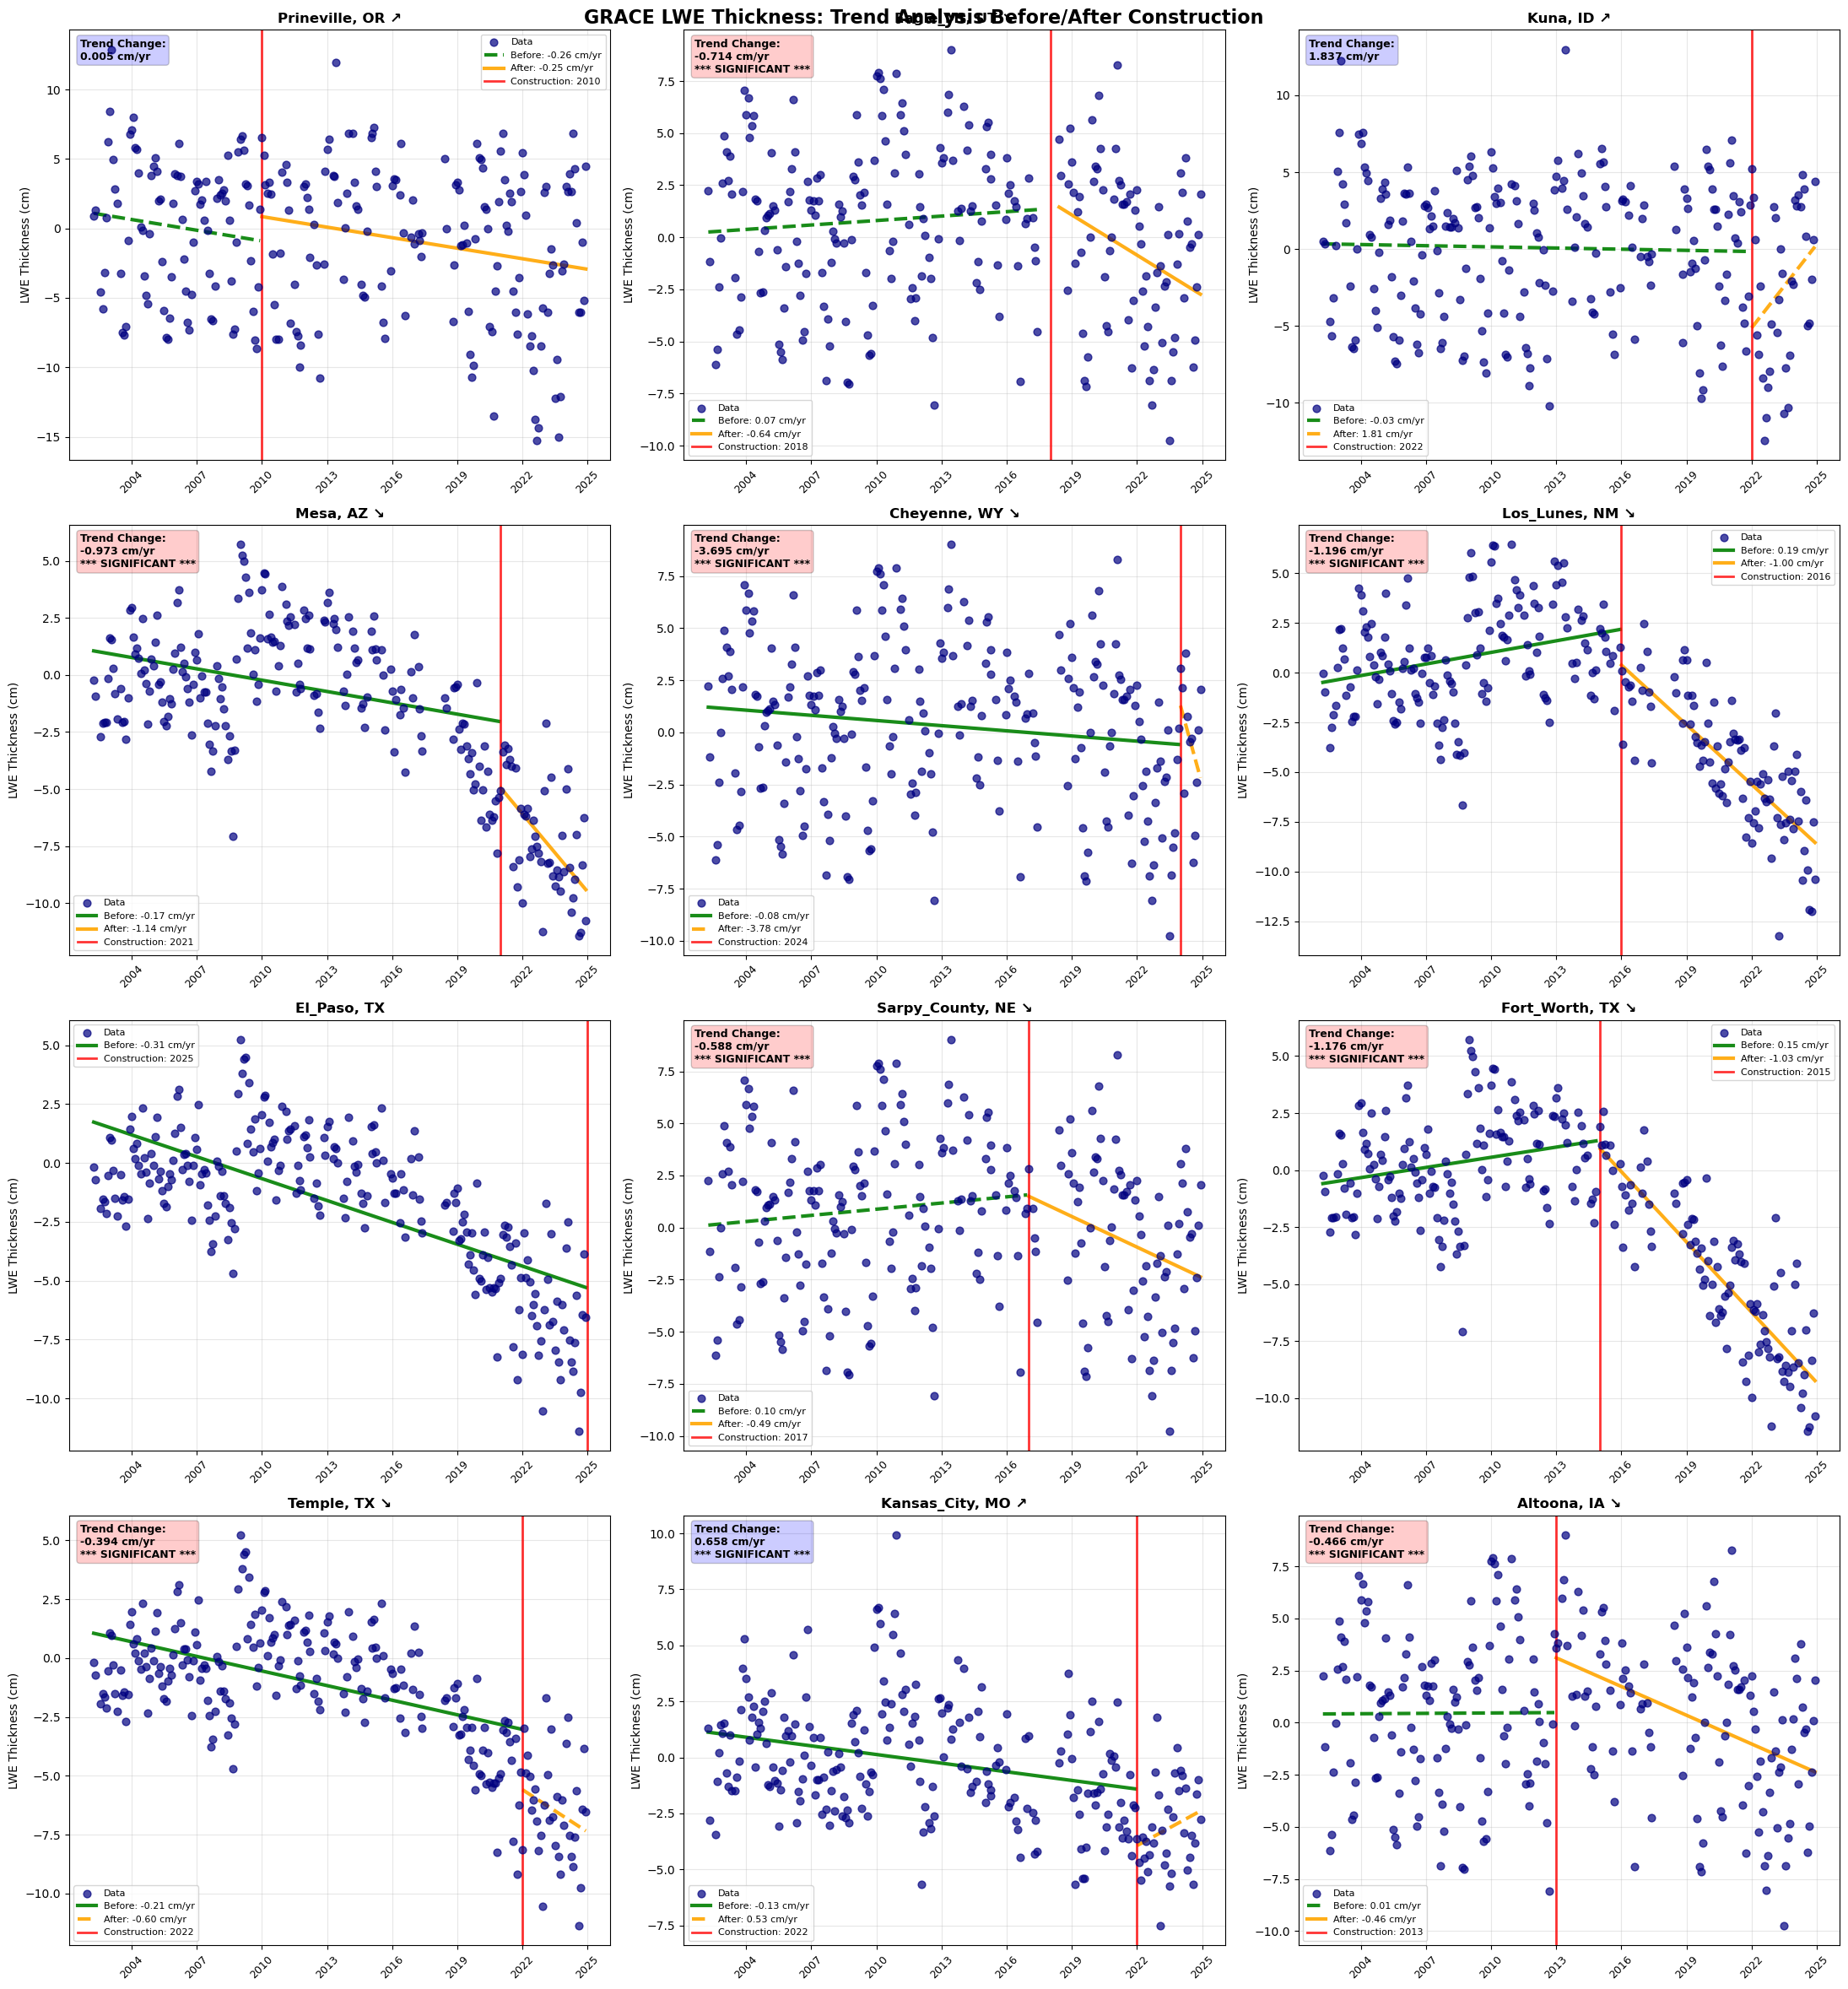

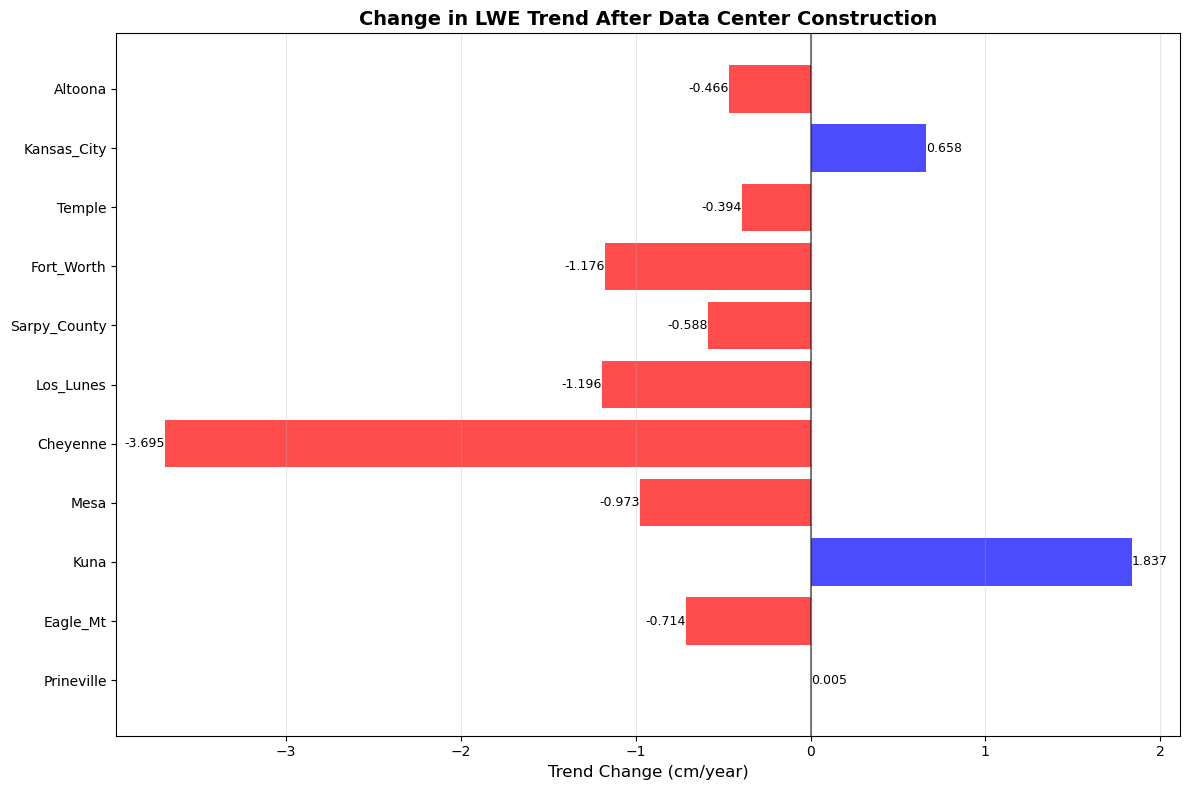

In [49]:
# Plot the trend analysis
n_locations = len(all_extractions)
n_cols = 3
n_rows = int(np.ceil(n_locations / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 6*n_rows))
axes = axes.flatten()

for i, (key, (formatted_times, lwe_thickness)) in enumerate(all_extractions.items()):
    lat, lon, center_name, state = key
    
    # Get results for this location
    location_name = f"{center_name.title()}, {state.upper()}"
    result_row = trend_results[trend_results['location'] == location_name].iloc[0]
    
    construction_date = result_row['construction_date']
    times_array = np.array(formatted_times)
    lwe_array = np.array(lwe_thickness)
    
    # Plot original data
    axes[i].scatter(formatted_times, lwe_thickness, c='navy', s=40, alpha=0.7, zorder=5, label='Data')
    
    # Split data at construction date
    before_mask = times_array < construction_date
    after_mask = times_array >= construction_date
    
    # Plot trend lines if sufficient data
    if result_row['points_before'] >= 3:
        before_times = times_array[before_mask]
        before_lwe = lwe_array[before_mask]
        before_numeric = np.array([(t - before_times[0]).days for t in before_times])
        
        # Fit and plot before trend
        model_before = LinearRegression().fit(before_numeric.reshape(-1, 1), before_lwe)
        pred_before = model_before.predict(before_numeric.reshape(-1, 1))
        
        line_style = '-' if result_row['p_value_before'] < 0.05 else '--'
        axes[i].plot(before_times, pred_before, color='green', linestyle=line_style, 
                    linewidth=3, alpha=0.9, 
                    label=f'Before: {result_row["slope_before_annual"]:.2f} cm/yr')
    
    if result_row['points_after'] >= 3:
        after_times = times_array[after_mask]
        after_lwe = lwe_array[after_mask]
        after_numeric = np.array([(t - after_times[0]).days for t in after_times])
        
        # Fit and plot after trend
        model_after = LinearRegression().fit(after_numeric.reshape(-1, 1), after_lwe)
        pred_after = model_after.predict(after_numeric.reshape(-1, 1))
        
        line_style = '-' if result_row['p_value_after'] < 0.05 else '--'
        axes[i].plot(after_times, pred_after, color='orange', linestyle=line_style, 
                    linewidth=3, alpha=0.9,
                    label=f'After: {result_row["slope_after_annual"]:.2f} cm/yr')
    
    # Mark construction date
    axes[i].axvline(x=construction_date, color='red', linestyle='-', linewidth=2, alpha=0.8,
                   label=f'Construction: {construction_date.year}')
    
    # Formatting
    title = f'{center_name.title()}, {state.upper()}'
    if not np.isnan(result_row['slope_diff_annual']):
        change_symbol = "↗" if result_row['slope_diff_annual'] > 0 else "↘"
        title += f' {change_symbol}'
    axes[i].set_title(title, fontsize=12, weight='bold')
    
    axes[i].set_ylabel('LWE Thickness (cm)', fontsize=10)
    axes[i].grid(True, alpha=0.3)
    
    # Format dates
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].xaxis.set_major_locator(mdates.YearLocator(3))
    axes[i].tick_params(axis='x', rotation=45, labelsize=9)
    
    # Legend
    axes[i].legend(fontsize=8, loc='best')
    
    # Statistics box
    if not np.isnan(result_row['slope_diff_annual']):
        change_color = 'red' if result_row['slope_diff_annual'] < 0 else 'blue'
        stats_text = f"Trend Change:\n{result_row['slope_diff_annual']:.3f} cm/yr"
        if result_row['slope_change_significant']:
            stats_text += "\n*** SIGNIFICANT ***"
        
        axes[i].text(0.02, 0.98, stats_text, transform=axes[i].transAxes, 
                    fontsize=9, weight='bold', verticalalignment='top',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=change_color, alpha=0.2))

# Hide empty subplots
for i in range(n_locations, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('GRACE LWE Thickness: Trend Analysis Before/After Construction', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

# Create a summary plot of slope changes
plt.figure(figsize=(12, 8))

valid_results = trend_results.dropna(subset=['slope_diff_annual'])
locations = [loc.split(',')[0] for loc in valid_results['location']]
slope_changes = valid_results['slope_diff_annual']
colors = ['red' if x < 0 else 'blue' for x in slope_changes]

bars = plt.barh(range(len(locations)), slope_changes, color=colors, alpha=0.7)
plt.yticks(range(len(locations)), locations)
plt.xlabel('Trend Change (cm/year)', fontsize=12)
plt.title('Change in LWE Trend After Data Center Construction', fontsize=14, weight='bold')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.5)
plt.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, slope_changes)):
    plt.text(value + (0.001 if value >= 0 else -0.001), i, f'{value:.3f}', 
             ha='left' if value >= 0 else 'right', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Analyzing Prineville, OR...
Analyzing Eagle_Mt, UT...
Analyzing Kuna, ID...
Analyzing Mesa, AZ...
Analyzing Cheyenne, WY...
Analyzing Los_Lunes, NM...
Analyzing El_Paso, TX...
Analyzing Sarpy_County, NE...
Analyzing Fort_Worth, TX...
Analyzing Temple, TX...
Analyzing Kansas_City, MO...
Analyzing Altoona, IA...
COMPREHENSIVE TREND ANALYSIS

Prineville, OR
Construction Date: Jan 2010
Total Data Points: 240

SIMPLE LINEAR REGRESSION (Entire Period):
  • Overall Trend: -0.151 cm/year **
  • R²: 0.037, p-value: 0.003

BREAKPOINT ANALYSIS (At Construction):
  BEFORE (90 points): -0.257 cm/year 
  AFTER (150 points): -0.253 cm/year **
  CHANGE: 0.005 cm/year (ACCELERATION)

Eagle_Mt, UT
Construction Date: Jan 2018
Total Data Points: 240

SIMPLE LINEAR REGRESSION (Entire Period):
  • Overall Trend: -0.081 cm/year **
  • R²: 0.021, p-value: 0.026

BREAKPOINT ANALYSIS (At Construction):
  BEFORE (163 points): 0.071 cm/year 
  AFTER (77 points): -0.643 cm/year **
  CHANGE: -0.714 cm/year (DECELER

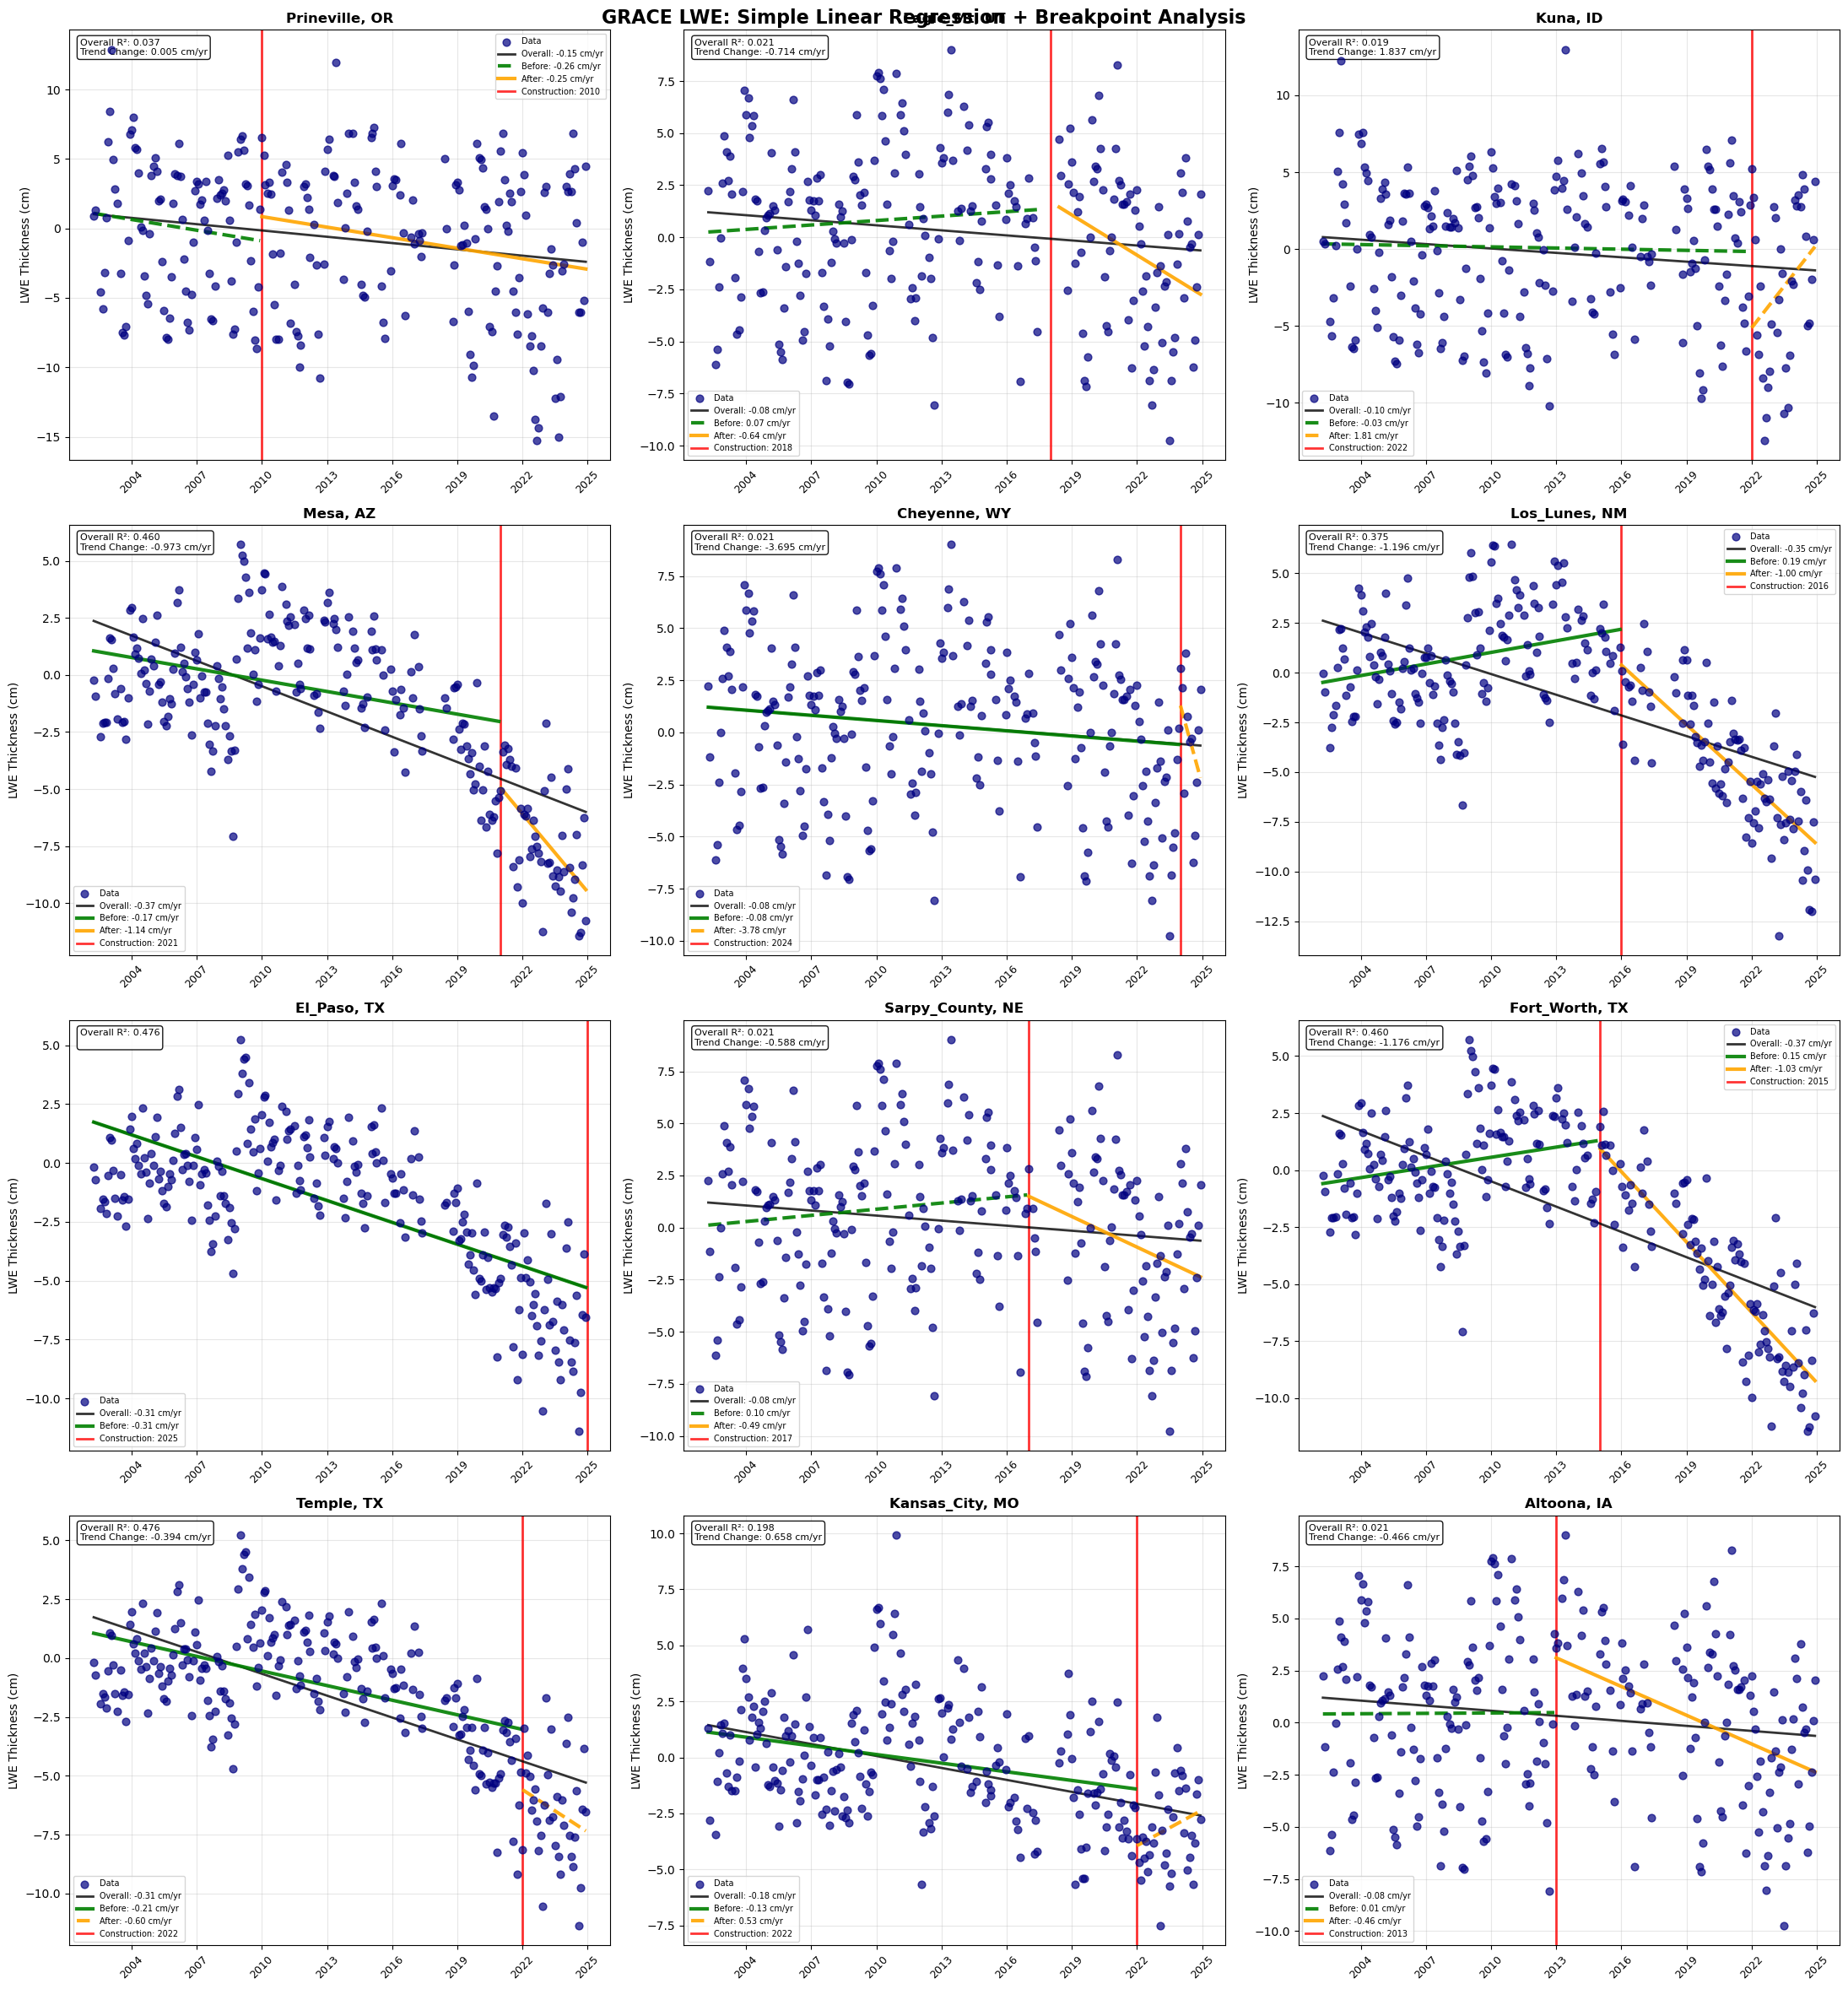


Comprehensive results saved to 'grace_comprehensive_trend_analysis.csv'


In [51]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from sklearn.linear_model import LinearRegression
import pandas as pd
from scipy import stats

def comprehensive_trend_analysis(all_extractions, data):
    """
    Perform both simple linear regression and breakpoint analysis
    """
    results = []
    
    for key, (formatted_times, lwe_thickness) in all_extractions.items():
        lat, lon, center_name, state = key
        
        # Get construction year
        construction_year = data[data['center_name'] == center_name]['year_broke_ground'].iloc[0]
        construction_date = datetime(construction_year, 1, 1)
        
        print(f"Analyzing {center_name.title()}, {state.upper()}...")
        
        # Convert to arrays
        times_array = np.array(formatted_times)
        lwe_array = np.array(lwe_thickness)
        
        # === SIMPLE LINEAR REGRESSION FOR ENTIRE TIME SERIES ===
        if len(times_array) >= 3:
            # Convert times to numeric (days since first observation)
            time_numeric = np.array([(t - times_array[0]).days for t in times_array])
            
            # Fit simple linear regression
            simple_model = LinearRegression().fit(time_numeric.reshape(-1, 1), lwe_array)
            simple_slope = simple_model.coef_[0]  # cm/day
            simple_intercept = simple_model.intercept_
            
            # Calculate R-squared and statistics
            simple_pred = simple_model.predict(time_numeric.reshape(-1, 1))
            ss_res = np.sum((lwe_array - simple_pred) ** 2)
            ss_tot = np.sum((lwe_array - np.mean(lwe_array)) ** 2)
            simple_r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            # Statistical significance
            slope_stat, intercept_stat, r_val, simple_p_value, std_err = stats.linregress(time_numeric, lwe_array)
        else:
            simple_slope = np.nan
            simple_intercept = np.nan
            simple_r2 = np.nan
            simple_p_value = np.nan
        
        # === BREAKPOINT ANALYSIS (BEFORE/AFTER CONSTRUCTION) ===
        # Split data at construction date
        before_mask = times_array < construction_date
        after_mask = times_array >= construction_date
        
        before_times = times_array[before_mask]
        before_lwe = lwe_array[before_mask]
        after_times = times_array[after_mask]
        after_lwe = lwe_array[after_mask]
        
        # Initialize breakpoint variables
        slope_before = np.nan
        slope_after = np.nan
        r2_before = np.nan
        r2_after = np.nan
        p_value_before = np.nan
        p_value_after = np.nan
        
        # Fit regression for BEFORE period
        if len(before_times) >= 3:
            before_numeric = np.array([(t - before_times[0]).days for t in before_times])
            model_before = LinearRegression().fit(before_numeric.reshape(-1, 1), before_lwe)
            
            slope_before = model_before.coef_[0]
            pred_before = model_before.predict(before_numeric.reshape(-1, 1))
            ss_res = np.sum((before_lwe - pred_before) ** 2)
            ss_tot = np.sum((before_lwe - np.mean(before_lwe)) ** 2)
            r2_before = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            slope_stat, intercept_stat, r_val, p_value_before, std_err = stats.linregress(before_numeric, before_lwe)
        
        # Fit regression for AFTER period
        if len(after_times) >= 3:
            after_numeric = np.array([(t - after_times[0]).days for t in after_times])
            model_after = LinearRegression().fit(after_numeric.reshape(-1, 1), after_lwe)
            
            slope_after = model_after.coef_[0]
            pred_after = model_after.predict(after_numeric.reshape(-1, 1))
            ss_res = np.sum((after_lwe - pred_after) ** 2)
            ss_tot = np.sum((after_lwe - np.mean(after_lwe)) ** 2)
            r2_after = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            slope_stat, intercept_stat, r_val, p_value_after, std_err = stats.linregress(after_numeric, after_lwe)
        
        # Calculate differences
        slope_difference = slope_after - slope_before if (not np.isnan(slope_before) and not np.isnan(slope_after)) else np.nan
        mean_before = np.mean(before_lwe) if len(before_lwe) > 0 else np.nan
        mean_after = np.mean(after_lwe) if len(after_lwe) > 0 else np.nan
        
        results.append({
            'location': f"{center_name.title()}, {state.upper()}",
            'center_name': center_name,
            'state': state,
            'construction_date': construction_date,
            'total_points': len(lwe_thickness),
            'points_before': len(before_lwe),
            'points_after': len(after_lwe),
            
            # Simple regression (entire series)
            'simple_slope_daily': simple_slope,
            'simple_slope_annual': simple_slope * 365.25 if not np.isnan(simple_slope) else np.nan,
            'simple_r2': simple_r2,
            'simple_p_value': simple_p_value,
            'simple_intercept': simple_intercept,
            
            # Breakpoint analysis
            'mean_before': mean_before,
            'mean_after': mean_after,
            'slope_before_daily': slope_before,
            'slope_after_daily': slope_after,
            'slope_before_annual': slope_before * 365.25 if not np.isnan(slope_before) else np.nan,
            'slope_after_annual': slope_after * 365.25 if not np.isnan(slope_after) else np.nan,
            'slope_diff_annual': slope_difference * 365.25 if not np.isnan(slope_difference) else np.nan,
            'r2_before': r2_before,
            'r2_after': r2_after,
            'p_value_before': p_value_before,
            'p_value_after': p_value_after
        })
    
    return pd.DataFrame(results)

# Perform comprehensive analysis
comprehensive_results = comprehensive_trend_analysis(all_extractions, data)

# Display results
print("COMPREHENSIVE TREND ANALYSIS")
print("=" * 80)

for idx, row in comprehensive_results.iterrows():
    print(f"\n{row['location']}")
    print(f"Construction Date: {row['construction_date'].strftime('%b %Y')}")
    print(f"Total Data Points: {row['total_points']}")
    
    # Simple regression results
    if not np.isnan(row['simple_slope_annual']):
        significance = "**" if row['simple_p_value'] < 0.05 else ""
        print(f"\nSIMPLE LINEAR REGRESSION (Entire Period):")
        print(f"  • Overall Trend: {row['simple_slope_annual']:.3f} cm/year {significance}")
        print(f"  • R²: {row['simple_r2']:.3f}, p-value: {row['simple_p_value']:.3f}")
    
    # Breakpoint results
    print(f"\nBREAKPOINT ANALYSIS (At Construction):")
    if row['points_before'] >= 3:
        sig_before = "**" if row['p_value_before'] < 0.05 else ""
        print(f"  BEFORE ({row['points_before']} points): {row['slope_before_annual']:.3f} cm/year {sig_before}")
    
    if row['points_after'] >= 3:
        sig_after = "**" if row['p_value_after'] < 0.05 else ""
        print(f"  AFTER ({row['points_after']} points): {row['slope_after_annual']:.3f} cm/year {sig_after}")
    
    if not np.isnan(row['slope_diff_annual']):
        change_type = "ACCELERATION" if row['slope_diff_annual'] > 0 else "DECELERATION"
        print(f"  CHANGE: {row['slope_diff_annual']:.3f} cm/year ({change_type})")

# Plot with both simple and breakpoint regressions
n_locations = len(all_extractions)
n_cols = 3
n_rows = int(np.ceil(n_locations / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 6*n_rows))
axes = axes.flatten()

for i, (key, (formatted_times, lwe_thickness)) in enumerate(all_extractions.items()):
    lat, lon, center_name, state = key
    
    # Get results for this location
    location_name = f"{center_name.title()}, {state.upper()}"
    result_row = comprehensive_results[comprehensive_results['location'] == location_name].iloc[0]
    
    construction_date = result_row['construction_date']
    times_array = np.array(formatted_times)
    lwe_array = np.array(lwe_thickness)
    
    # Plot original data
    axes[i].scatter(formatted_times, lwe_thickness, c='navy', s=40, alpha=0.7, zorder=5, label='Data')
    
    # === SIMPLE LINEAR REGRESSION LINE (ENTIRE SERIES) ===
    if not np.isnan(result_row['simple_slope_daily']):
        time_numeric = np.array([(t - times_array[0]).days for t in times_array])
        simple_model = LinearRegression().fit(time_numeric.reshape(-1, 1), lwe_array)
        simple_pred = simple_model.predict(time_numeric.reshape(-1, 1))
        
        line_style = '-' if result_row['simple_p_value'] < 0.05 else ':'
        axes[i].plot(times_array, simple_pred, color='black', linestyle=line_style, 
                    linewidth=2, alpha=0.8, zorder=3,
                    label=f'Overall: {result_row["simple_slope_annual"]:.2f} cm/yr')
    
    # === BREAKPOINT REGRESSION LINES ===
    # Split data at construction date
    before_mask = times_array < construction_date
    after_mask = times_array >= construction_date
    
    # Before construction trend
    if result_row['points_before'] >= 3:
        before_times = times_array[before_mask]
        before_lwe = lwe_array[before_mask]
        before_numeric = np.array([(t - before_times[0]).days for t in before_times])
        
        model_before = LinearRegression().fit(before_numeric.reshape(-1, 1), before_lwe)
        pred_before = model_before.predict(before_numeric.reshape(-1, 1))
        
        line_style = '-' if result_row['p_value_before'] < 0.05 else '--'
        axes[i].plot(before_times, pred_before, color='green', linestyle=line_style, 
                    linewidth=3, alpha=0.9, zorder=4,
                    label=f'Before: {result_row["slope_before_annual"]:.2f} cm/yr')
    
    # After construction trend
    if result_row['points_after'] >= 3:
        after_times = times_array[after_mask]
        after_lwe = lwe_array[after_mask]
        after_numeric = np.array([(t - after_times[0]).days for t in after_times])
        
        model_after = LinearRegression().fit(after_numeric.reshape(-1, 1), after_lwe)
        pred_after = model_after.predict(after_numeric.reshape(-1, 1))
        
        line_style = '-' if result_row['p_value_after'] < 0.05 else '--'
        axes[i].plot(after_times, pred_after, color='orange', linestyle=line_style, 
                    linewidth=3, alpha=0.9, zorder=4,
                    label=f'After: {result_row["slope_after_annual"]:.2f} cm/yr')
    
    # Mark construction date
    axes[i].axvline(x=construction_date, color='red', linestyle='-', linewidth=2, alpha=0.8, zorder=2,
                   label=f'Construction: {construction_date.year}')
    
    # Formatting
    title = f'{center_name.title()}, {state.upper()}'
    axes[i].set_title(title, fontsize=12, weight='bold')
    axes[i].set_ylabel('LWE Thickness (cm)', fontsize=10)
    axes[i].grid(True, alpha=0.3, zorder=1)
    
    # Format dates
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].xaxis.set_major_locator(mdates.YearLocator(3))
    axes[i].tick_params(axis='x', rotation=45, labelsize=9)
    
    # Legend
    axes[i].legend(fontsize=7, loc='best')
    
    # Statistics box comparing simple vs breakpoint
    stats_text = f"Overall R²: {result_row['simple_r2']:.3f}\n"
    if not np.isnan(result_row['slope_diff_annual']):
        stats_text += f"Trend Change: {result_row['slope_diff_annual']:.3f} cm/yr"
    
    axes[i].text(0.02, 0.98, stats_text, transform=axes[i].transAxes, 
                fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

# Hide empty subplots
for i in range(n_locations, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('GRACE LWE: Simple Linear Regression + Breakpoint Analysis', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

# Save comprehensive results
comprehensive_results.to_csv('grace_comprehensive_trend_analysis.csv', index=False)
print(f"\nComprehensive results saved to 'grace_comprehensive_trend_analysis.csv'")